# Semana 3 — SARIMAX y variables exógenas

**Objetivo.** Modelar PM2.5 con estacionalidad explícita, evaluar el valor marginal de meteorología y comprender que una covariable futura debe estar disponible o pronosticada.

- **Dataset:** `data/03_beijing/beijing_pm25.csv`
- **Duración:** 4–5 horas
- **Target:** `pm2.5` (concentración horaria)
- **Seed:** 42

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

**Modo de uso (clase ejecutable).** Cada celda de código viene precedida por markdown que explica *qué hace*, *por qué importa* y *cómo interpretar la salida*; los comentarios `#` dentro del código refuerzan la lectura línea a línea. La semilla global (seed) fija la reproducibilidad: cualquier componente aleatorio produce la misma secuencia en cada ejecución. El hilo conductor de la semana es el caso de negocio de alertas de calidad del aire y la pregunta de si las covariables meteorológicas estarán disponibles en producción.


## Caso de negocio: alertas de calidad del aire

**Contexto.** Una autoridad ambiental de Beijing necesita pronósticos horarios de PM2.5 para tres decisiones operativas: (1) **emitir alertas** a la población cuando se superen umbrales de contaminación; (2) **restringir operaciones** (circulación, actividad industrial) en episodios agudos; y (3) **planificar el monitoreo** (mantenimiento de estaciones, campañas de medición).

**Costo del error.** El error no es simétrico:
- *Falso negativo* (no alertar cuando habrá un pico): exposición innecesaria de la población; el costo es de salud pública.
- *Falso positivo* (alertar sin que ocurra el pico): pérdida de credibilidad, paradas industriales y restricciones innecesarias.

En números del notebook, un MAE de ~85–104 µg/m³ (Sección 3) equivale a desviaciones del tamaño de la diferencia entre un día "moderado" y uno "insalubre": por eso la métrica por nivel (4.7) muestra que el error en episodios altos (178.9 de media) es el más costoso.

**Pregunta guía de la semana:** *¿Las variables exógenas estarán realmente disponibles en producción?* En validación se usan temperaturas y lluvia *observadas*; en producción, esos valores futuros no existen todavía: habría que pronosticarlos. Este notebook compara SARIMA (sin exógenas) con SARIMAX (con exógenas) para responder: ¿cuánto gana el modelo si las covariables fueran perfectas (techo oracle), y qué implica ese techo para el despliegue?

### Tabla de disponibilidad de covariables

| Covariable | Disponible en producción | Uso honesto |
|---|---|---|
| PM2.5 pasado | Sí (mediciones históricas) | Target y rezagos autorregresivos |
| Calendario (hora, día, mes, festivos) | Sí (se conoce con antelación) | Estacionalidad y efectos de calendario |
| Temperatura, punto de rocío, presión, viento, lluvia observados | **No** en el momento de pronosticar | Requieren pronóstico meteorológico externo o simulación con error |
| Dirección del viento (`cbwd`) | No sin pronóstico meteorológico | Igual que las numéricas: escenario oracle si se usa la observada |

**Anti-patrón de la semana (escenario oracle).** Usar clima observado en test como si estuviera disponible en producción. Produce un *techo optimista*: la mejora de SARIMAX medida así no es alcanzable operativamente sin un proveedor de pronóstico meteorológico.

> *Nivel de análisis: concentración de PM2.5 agregada por estación y hora, no exposición individual. Las alertas resultantes son decisiones de salud pública a nivel poblacional, no un diagnóstico de exposición de una persona concreta.*

### 0.1 Imports y reproducibilidad

**Qué hace.** Fija la semilla aleatoria global (seed) e importa las librerías de manipulación, estadística y modelado que se usarán en todo el notebook.

**Por qué importa.** SARIMAX y los tests estadísticos dependen de optimización numérica; fijar la semilla hace que los resultados sean deterministas y comparables entre ejecuciones (reproducibilidad).

**Cómo interpretar.** La celda no produce salida visible; su efecto es de configuración. Observe que `SEED=42` se define como constante con nombre para que cualquier cambio futuro sea explícito y rastreable.


In [1]:
# Imports y configuracion global del notebook.
from __future__ import annotations
from pathlib import Path
import random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
# Semilla global (seed): hace determinista cualquier componente aleatorio.
SEED=42
random.seed(SEED); np.random.seed(SEED)
# Se silencian warnings numericos para mantener la salida legible.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="notebook")
plt.rcParams["figure.figsize"]=(12,4)


### 0.2 Ruta portable

**Qué hace.** Busca el CSV del dataset entre rutas candidatas relativas, de modo que el notebook funcione tanto desde la raíz del repositorio como desde `notebooks/`.

**Por qué importa.** La portabilidad de rutas evita errores de `FileNotFoundError` al cambiar de entorno y es el primer paso de un contrato de datos reproducible.

**Cómo interpretar.** La salida imprime la ruta absoluta resuelta; la comprobación `assert DATA_PATH is not None` garantiza que el dataset existe antes de continuar.


In [2]:
# Rutas candidatas: desde la raiz del repo o desde notebooks/.
CANDIDATES=[Path("data/03_beijing/beijing_pm25.csv"),Path("../data/03_beijing/beijing_pm25.csv")]
# Se elige la primera ruta existente y se aborta si no hay ninguna.
DATA_PATH=next((p for p in CANDIDATES if p.exists()),None)
assert DATA_PATH is not None
print(DATA_PATH.resolve())


/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/03_beijing/beijing_pm25.csv


### 0.3 Carga

**Qué hace.** Lee el CSV con `pd.read_csv` y valida la forma esperada (43,800 filas × 14 columnas) mediante una aserción.

**Por qué importa.** La aserción es un contrato de datos: si el archivo cambiara de dimensiones, el notebook falla de forma temprana y explícita en lugar de propagar errores silenciosos.

**Cómo interpretar.** `raw.info()` muestra tipos y nulos por columna: `pm2.5` es `float64` con 2,043 ausencias; las covariables numéricas (`DEWP`, `TEMP`, `PRES`, `Iws`, `Is`, `Ir`) están completas.


In [3]:
# Carga del CSV; el contrato exige 43,800 filas x 14 columnas.
raw=pd.read_csv(DATA_PATH,parse_dates=["ds"])
assert raw.shape==(43_800,14),raw.shape
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      43800 non-null  datetime64[ns]
 1   No      43800 non-null  int64         
 2   year    43800 non-null  int64         
 3   month   43800 non-null  int64         
 4   day     43800 non-null  int64         
 5   hour    43800 non-null  int64         
 6   pm2.5   41757 non-null  float64       
 7   DEWP    43800 non-null  int64         
 8   TEMP    43800 non-null  float64       
 9   PRES    43800 non-null  float64       
 10  cbwd    43800 non-null  object        
 11  Iws     43800 non-null  float64       
 12  Is      43800 non-null  int64         
 13  Ir      43800 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(8), object(1)
memory usage: 4.7+ MB


### 0.4 Schema

**Qué hace.** Define constantes con nombre (`TARGET`, `EXOG_NUM`) y verifica que las columnas del dataset coinciden exactamente con el esquema esperado.

**Por qué importa.** La variable objetivo (`pm2.5`) y el conjunto de covariables exógenas (`DEWP`, `TEMP`, `PRES`, `Iws`, `Is`, `Ir`) son la base de todo el modelado; nombrarlas evita errores de tipeo y documenta el contrato.

**Cómo interpretar.** El mensaje `Schema OK` confirma que no faltan ni sobran columnas y que la serie temporal es monótona creciente y sin timestamps duplicados.


In [4]:
# Constantes con nombre: target y exogenas numericas del contrato.
TARGET="pm2.5"; EXOG_NUM=["DEWP","TEMP","PRES","Iws","Is","Ir"]
EXPECTED={"ds","No","year","month","day","hour",TARGET,"cbwd",*EXOG_NUM}
# Aserciones de schema: columnas exactas y serie ordenada sin duplicados.
assert set(raw.columns)==EXPECTED
assert raw.ds.is_monotonic_increasing and raw.ds.is_unique
print("Schema OK")


Schema OK


### 0.5 Nulos

**Qué hace.** Cuantifica los valores ausentes por columna y su porcentaje sobre el total.

**Por qué importa.** Los 2,043 nulos (4.66 %) están todos en `pm2.5`; ninguna covariable tiene ausencias. Esto delimita el problema: hay que imputar el target, no las exógenas.

**Cómo interpretar.** La tabla resultante es la evidencia objetiva de la magnitud del problema de nulos que se abordará en la Sección 1.


In [5]:
# Auditoria de nulos: conteo y porcentaje por columna.
nulls=raw.isna().sum().to_frame("n_missing"); nulls["pct"]=100*nulls.n_missing/len(raw); nulls.query("n_missing>0")


,n_missing,pct
pm2.5,2043,4.664384


### 0.6 Rango y frecuencia

**Qué hace.** Imprime el rango temporal y la distribución de diferencias entre timestamps consecutivos.

**Por qué importa.** Confirmar la frecuencia horaria uniforme es un prerrequisito para definir el horizonte (168 h = 7 días) y la estacionalidad (24 h).

**Cómo interpretar.** La serie va de 2010-01-02 a 2014-12-31 y todas las diferencias son de exactamente 1 hora (43,799 transiciones), lo que indica una rejilla horaria sin saltos.


In [6]:
# Rango temporal y diferencias entre timestamps consecutivos.
print(raw.ds.min(),raw.ds.max()); delta=raw.ds.diff().dropna(); print(delta.value_counts().head())


2010-01-02 00:00:00 2014-12-31 23:00:00
ds
0 days 01:00:00    43799
Name: count, dtype: int64


### 0.7 Gaps temporales

**Qué hace.** Compara la rejilla esperada de timestamps horarios contra los timestamps presentes.

**Por qué importa.** Distingue dos problemas distintos: timestamps faltantes (hueco en la rejilla) y valores ausentes del target (NaN en una fila existente). Su tratamiento y su impacto en el modelado son diferentes.

**Cómo interpretar.** Hay 0 timestamps faltantes y 2,043 valores de PM2.5 ausentes: el problema es de *valores*, no de *rejilla*.


In [7]:
# Rejilla esperada vs timestamps presentes: separa huecos de valores ausentes.
expected=pd.date_range(raw.ds.min(),raw.ds.max(),freq="h"); missing_ts=expected.difference(raw.ds)
print("Timestamps faltantes:",len(missing_ts),"PM2.5 faltantes:",raw[TARGET].isna().sum())


Timestamps faltantes: 0 PM2.5 faltantes: 2043


### 0.8 Duplicados

**Qué hace.** Cuenta filas exactamente duplicadas y timestamps repetidos.

**Por qué importa.** Los duplicados inflan artificialmente la muestra y pueden romper el supuesto de frecuencia regular del modelo SARIMAX.

**Cómo interpretar.** Ambas cifras son 0: el dataset no requiere deduplicación y la rejilla es limpia.


In [8]:
# Duplicados a nivel de fila y de timestamp.
print("Filas duplicadas:",raw.duplicated().sum()); print("Timestamps duplicados:",raw.ds.duplicated().sum())


Filas duplicadas: 0
Timestamps duplicados: 0


### 0.9 Estadísticos del target

**Qué hace.** Calcula estadísticos descriptivos de `pm2.5` excluyendo nulos, con percentiles extremos.

**Por qué importa.** Define la escala y la asimetría del problema: la media (98.6) supera a la mediana (72), lo que indica cola derecha con episodios de contaminación extrema.

**Cómo interpretar.** El rango va de 0 a 994 µg/m³, con percentil 99 en 420: los errores de pronóstico en episodios altos dominarán métricas como RMSE. Esto conecta con el costo del error en salud pública.


In [9]:
# Estadisticos del target con percentiles extremos; excluye nulos.
raw[TARGET].describe(percentiles=[.01,.25,.5,.75,.9,.95,.99]).to_frame().T


,count,mean,std,min,1%,25%,50%,75%,90%,95%,99%,max
pm2.5,41757.0,98.613215,92.050387,0.0,6.0,29.0,72.0,137.0,221.0,284.0,420.0,994.0


### 0.10 Dirección del viento

**Qué hace.** Cuenta los valores de la variable categórica `cbwd`.

**Por qué importa.** `cbwd` (dirección combinada del viento) es nominal: imponer un orden arbitrario (1,2,3,4) sería un error de codificación. En la Sección 3 se codificará como one-hot antes de entrar al modelo.

**Cómo interpretar.** Hay cuatro categorías con frecuencias muy distintas (SE 15,290; NW 14,130; cv 9,384; NE 4,996). El desbalance implica que algunos coeficientes one-hot se estimarán con menos datos.


In [10]:
# Frecuencias de la variable categorica de direccion del viento.
raw.cbwd.value_counts(dropna=False).to_frame("count")


,count
cbwd,
SE,15290
NW,14130
cv,9384
NE,4996


## 1. Análisis previo (pre-modeling)

Se estudian patrón temporal, estacionalidad, estacionariedad, outliers, cambios y alternativas de imputación.

**Objetivo de la sección.** Antes de modelar hay que responder tres preguntas: ¿qué estructura temporal domina la serie?, ¿es estacionaria o hay que diferenciar?, y ¿cómo tratar los 2,043 nulos sin filtrar información del futuro? Cada subsección produce una evidencia que luego se materializa en decisiones de modelado (órdenes SARIMA, imputación causal, exógenas).


### 1.1 Serie completa

**Qué hace.** Dibuja la serie horaria completa de PM2.5 dejando visibles los huecos de valores ausentes.

**Por qué importa.** La vista global permite reconocer estacionalidad anual, episodios extremos y la magnitud de los gaps antes de cualquier transformación.

**Cómo interpretar.** Se observan ciclos invernales pronunciados (picos altos en invierno) y una cola de valores extremos. Los cortes en la línea corresponden a los 2,043 nulos.


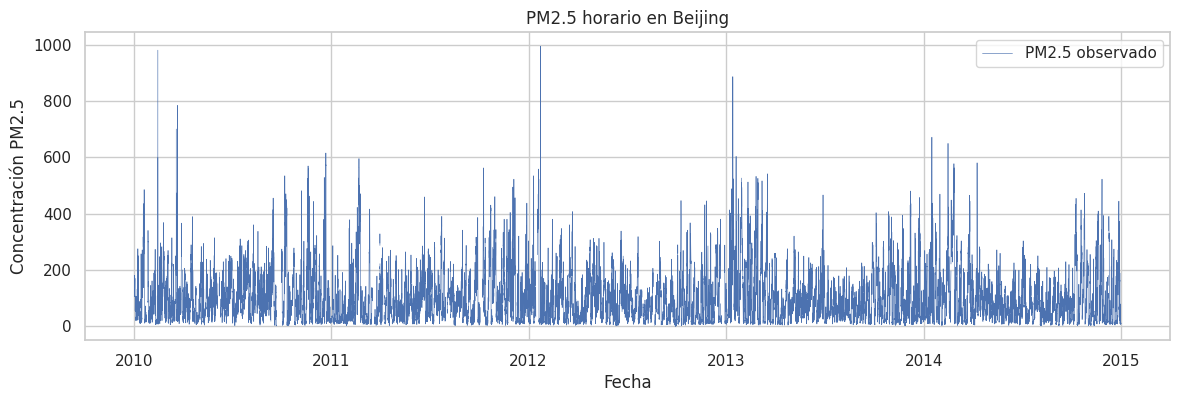

In [11]:
# Serie completa: los huecos (NaN) se dejan visibles en el grafico.
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(raw.ds,raw[TARGET],lw=.45,label="PM2.5 observado"); ax.set(title="PM2.5 horario en Beijing",xlabel="Fecha",ylabel="Concentración PM2.5"); ax.legend(); plt.show()


### 1.2 Zoom mensual

**Qué hace.** Recorta un mes (enero de 2014) para inspeccionar la dinámica de corto plazo.

**Por qué importa.** A escala mensual se aprecia la *persistencia*: los episodios de contaminación duran varios días y no cambian de nivel hora a hora de forma independiente.

**Cómo interpretar.** La serie muestra tramos sostenidos por encima de 100 µg/m³ seguidos de descensos bruscos: esta persistencia es la que los modelos autorregresivos intentan capturar.


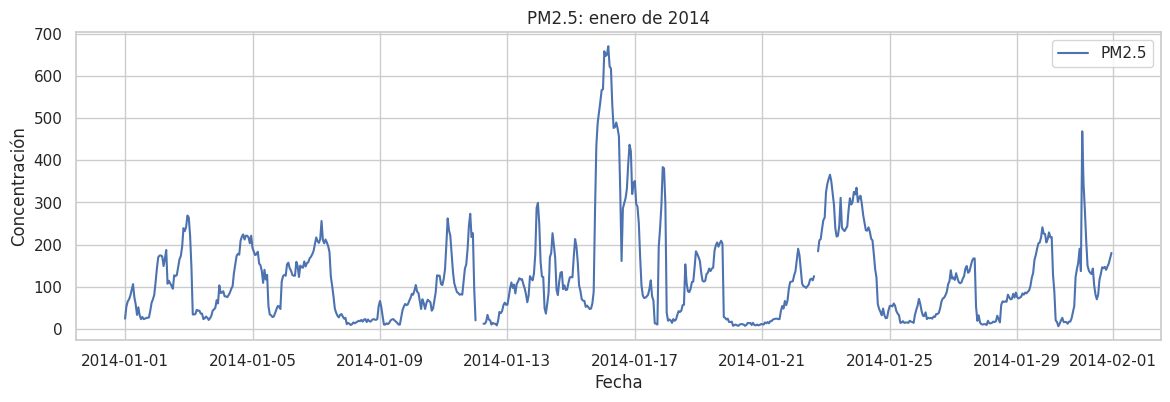

In [12]:
# Zoom a enero 2014: persistencia y episodios de corto plazo.
z=raw.set_index("ds").loc["2014-01-01":"2014-01-31",TARGET]; fig,ax=plt.subplots(figsize=(14,4)); ax.plot(z.index,z,label="PM2.5"); ax.set(title="PM2.5: enero de 2014",xlabel="Fecha",ylabel="Concentración"); ax.legend(); plt.show()


### 1.3 Perfil horario

**Qué hace.** Agrega el target por hora del día, comparando media y mediana.

**Por qué importa.** El perfil horario revela la estacionalidad intradía (ciclo de 24 h) que justificará el término estacional (1,0,0,24) del modelo.

**Cómo interpretar.** Si la media y la mediana se separan en ciertas horas, hay episodios extremos concentrados; el patrón horario de fondo se lee mejor con la mediana.


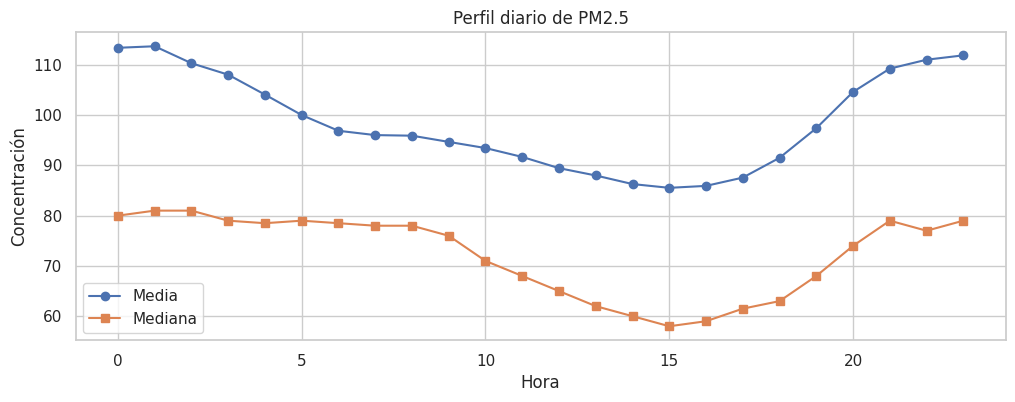

In [13]:
# Perfil horario: media vs mediana por hora del dia.
prof=raw.assign(h=raw.ds.dt.hour).groupby("h")[TARGET].agg(["mean","median"]); fig,ax=plt.subplots(); ax.plot(prof.index,prof["mean"],marker="o",label="Media"); ax.plot(prof.index,prof["median"],marker="s",label="Mediana"); ax.set(title="Perfil diario de PM2.5",xlabel="Hora",ylabel="Concentración"); ax.legend(); plt.show()


### 1.4 Perfil semanal

**Qué hace.** Promedia PM2.5 por día de la semana.

**Por qué importa.** Diferencia entre días laborables y fin de semana por emisiones; alimenta la decisión de si incluir estacionalidad semanal.

**Cómo interpretar.** La forma del perfil indica si existe un efecto de fin de semana relevante. En este notebook la estacionalidad diaria domina, pero el perfil semanal se documenta como evidencia.


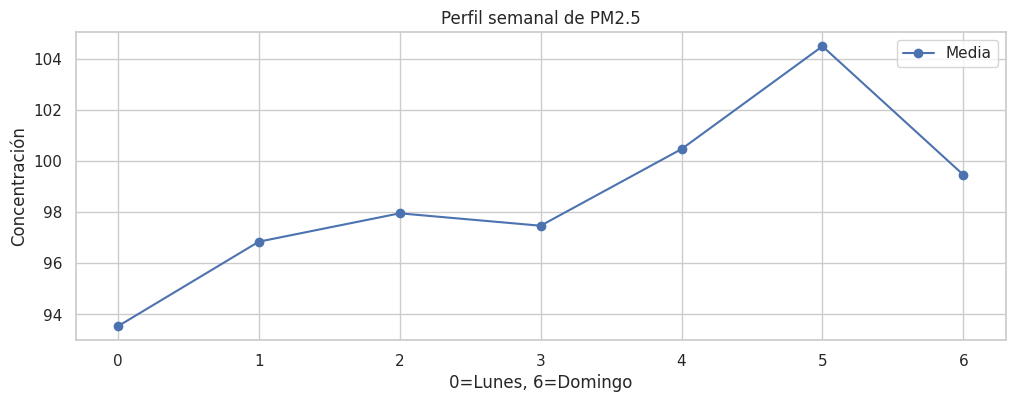

In [14]:
# Perfil semanal: media por dia de la semana (0=Lunes).
prof=raw.assign(dow=raw.ds.dt.dayofweek).groupby("dow")[TARGET].mean(); fig,ax=plt.subplots(); ax.plot(prof.index,prof,marker="o",label="Media"); ax.set(title="Perfil semanal de PM2.5",xlabel="0=Lunes, 6=Domingo",ylabel="Concentración"); ax.legend(); plt.show()


### 1.5 Perfil mensual

**Qué hace.** Agrega el target por mes (mediana) para describir la estacionalidad anual.

**Por qué importa.** El ciclo anual en Beijing es fuerte (inviernos contaminados). Aunque el modelo usa ventanas de 180 días, la estacionalidad mensual explica por qué los folds de invierno tendrán errores distintos a los de otoño.

**Cómo interpretar.** La curva mensual muestra los meses de mayor concentración; sirve para anticipar que la comparación SARIMA vs SARIMAX debe leerse fold a fold, no solo con el promedio.


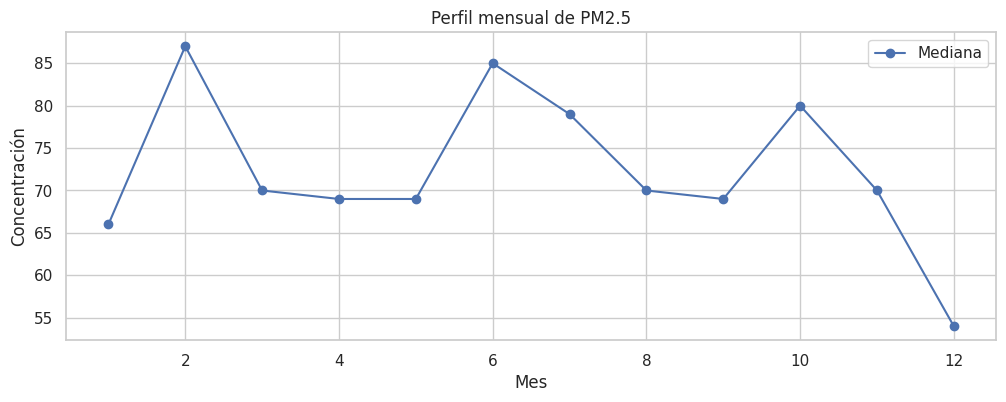

In [15]:
# Perfil mensual: mediana por mes (climatologia).
prof=raw.assign(m=raw.ds.dt.month).groupby("m")[TARGET].median(); fig,ax=plt.subplots(); ax.plot(prof.index,prof,marker="o",label="Mediana"); ax.set(title="Perfil mensual de PM2.5",xlabel="Mes",ylabel="Concentración"); ax.legend(); plt.show()


### 1.6 Tratamiento de nulos

**Qué hace.** Compara tres estrategias para los 2,043 nulos: eliminación, forward-fill causal (solo usa valores pasados) e interpolación temporal bilateral.

**Por qué importa.** **Anti-patrón de la semana:** la interpolación bilateral usa una observación *posterior* al hueco; aplicada antes del split, filtraría información del futuro hacia el pasado (leakage). Por eso aquí se muestra solo con fines comparativos y en la Sección 2 la imputación operativa se reajusta dentro de cada fold.

**Cómo interpretar.** En la ventana alrededor del primer gap (2010-01-23 17:00), `ffill` arrastra el último valor observado (22.0) y `interpolate_bilateral` también, pero la diferencia conceptual es clave: solo el método causal puede usarse en producción sin mirar el futuro.


### 1.7 Comparación de estrategias

**Qué hace.** Construye una tabla con las tres estrategias alrededor del primer gap interior para inspeccionar sus diferencias numéricas.

**Por qué importa.** La comparación visual y numérica muestra cuánto difieren las estrategias en un caso concreto, y por qué la elección debe estar guiada por causalidad, no solo por conveniencia.

**Cómo interpretar.** En las filas del hueco las tres series coinciden en 22.0 (el último valor previo); la tabla también expone dónde `original` es NaN. La decisión final se documenta en 1.9.


In [16]:
# Primer gap interior y ventana de comparacion (12 h antes, 24 h despues).
s=raw.set_index("ds")[TARGET]; first_gap=s[s.isna()].index[0]; window=s.loc[first_gap-pd.Timedelta(hours=12):first_gap+pd.Timedelta(hours=24)]
# Tres estrategias: original, forward-fill causal e interpolacion bilateral (usa futuro).
compare=pd.DataFrame({"original":window,"ffill":window.ffill(),"interpolate_bilateral":window.interpolate("time")}); compare.head(20)


,original,ffill,interpolate_bilateral
ds,,,
2010-01-23 05:00:00,16.0,16.0,16.0
2010-01-23 06:00:00,22.0,22.0,22.0
2010-01-23 07:00:00,24.0,24.0,24.0
2010-01-23 08:00:00,24.0,24.0,24.0
2010-01-23 09:00:00,41.0,41.0,41.0
2010-01-23 10:00:00,23.0,23.0,23.0
2010-01-23 11:00:00,19.0,19.0,19.0
2010-01-23 12:00:00,15.0,15.0,15.0
2010-01-23 13:00:00,19.0,19.0,19.0


### 1.8 Visualización de imputación

**Qué hace.** Dibuja las tres estrategias alrededor del gap para compararlas visualmente.

**Por qué importa.** Un gráfico hace explícito el comportamiento de cada método en la vecindad del hueco: arrastre de nivel, suavizado o discontinuidad.

**Cómo interpretar.** La proximidad de las curvas en este gap concreto sugiere que la elección del método tendrá poco efecto aquí; el efecto global se evalúa en la Sección 3 mediante la validación rolling-origin.


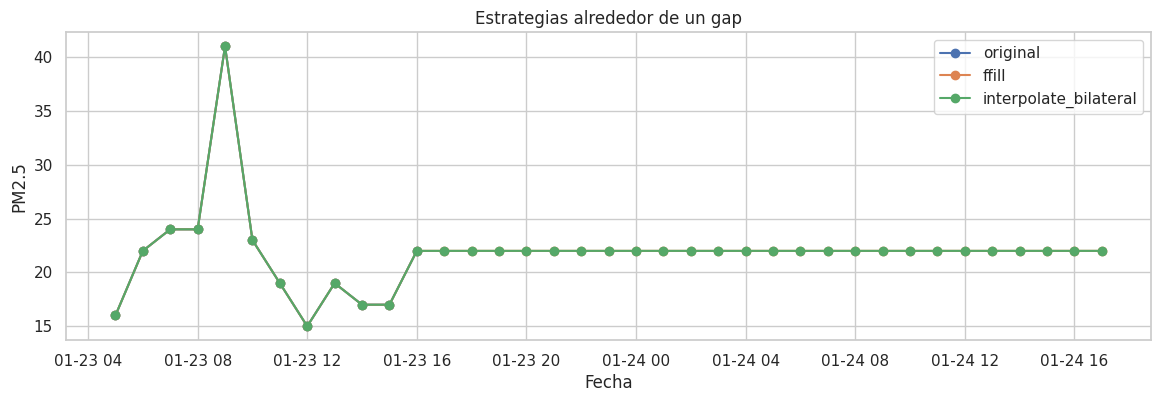

In [17]:
# Visualizacion de las tres estrategias alrededor del gap.
fig,ax=plt.subplots(figsize=(14,4));
for col in compare: ax.plot(compare.index,compare[col],marker="o",label=col)
ax.set(title="Estrategias alrededor de un gap",xlabel="Fecha",ylabel="PM2.5"); ax.legend(); plt.show()


### 1.9 Decisión de imputación

**Qué hace.** Documenta la política adoptada: forward-fill causal con límite de 24 horas dentro de cada fold y, para gaps más largos, la mediana calculada *solo con datos de train*. La celda siguiente cuantifica la distribución de longitudes de gap.

**Por qué importa.** Es la primera decisión metodológica con impacto directo en el error: imputar con datos futuros o con estadísticas globales (que incluyen test) inflaría artificialmente la calidad de la validación.

**Cómo interpretar.** Los 213 gaps tienen una longitud mediana de 1 hora, pero el máximo llega a 155 horas: el límite de 24 h hace que los gaps largos caigan en el fallback de mediana de train, una política causal y estable.


In [18]:
# Longitudes de los gaps de PM2.5: cuantos hay y que tan largos son.
gap_lengths=s.isna().astype(int).groupby(s.notna().cumsum()).sum(); gap_lengths=gap_lengths[gap_lengths>0]
print(gap_lengths.describe(),"máximo=",gap_lengths.max())


count    213.000000
mean       9.591549
std       21.441393
min        1.000000
25%        1.000000
50%        1.000000
75%        7.000000
max      155.000000
Name: pm2.5, dtype: float64 máximo= 155


### 1.10 Serie EDA

**Qué hace.** Construye una versión imputada de la serie únicamente para los análisis descriptivos (STL, ACF/PACF, tests de estacionariedad), con ffill causal limitado a 24 h y fallback a la mediana.

**Por qué importa.** Los diagnósticos descriptivos necesitan una serie sin NaN, pero esta versión *no* debe confundirse con la imputación de validación: los folds de la Sección 2 recalculan el fallback dentro de train.

**Cómo interpretar.** La salida `0` confirma que la serie EDA quedó completa; es una serie de *diagnóstico*, no de modelado.


In [19]:
# Serie EDA: ffill causal (24 h) con fallback de mediana; solo para diagnostico.
eda_y=s.ffill(limit=24).fillna(s.median()); print(eda_y.isna().sum())


0


### 1.11 STL diaria

**Qué hace.** Ajusta una descomposición STL robusta con periodo 24 h sobre los dos últimos años.

**Por qué importa.** STL separa tendencia, estacionalidad y residuo, permitiendo medir la fuerza estacional y detectar outliers sobre el residuo.

**Cómo interpretar.** Observe la magnitud del componente estacional frente al residuo: una estacionalidad diaria relativamente débil es consistente con que el ciclo de 24 h explique poco de la varianza total en esta serie de contaminación.


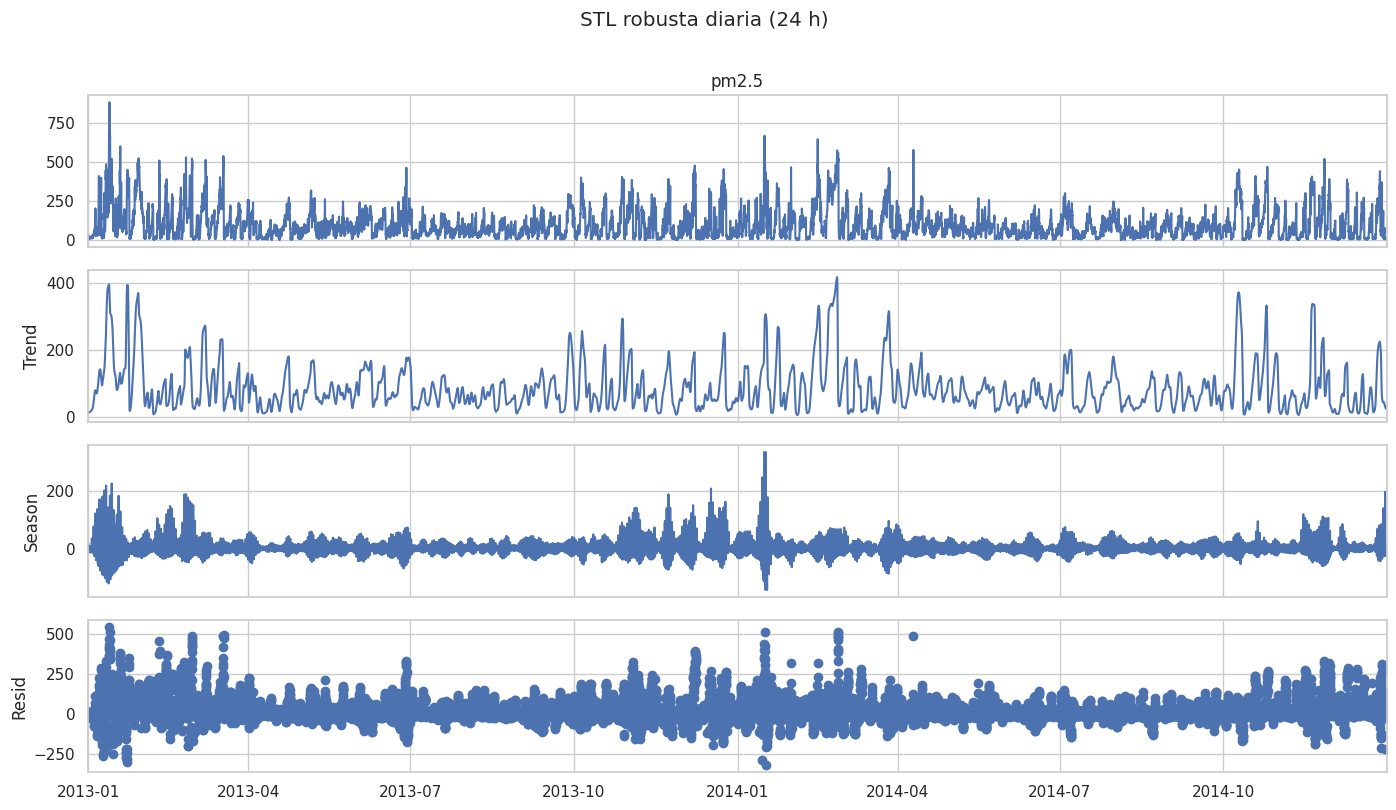

In [20]:
# STL robusta diaria (periodo 24) sobre 2013-2014.
stl24=STL(eda_y.loc["2013-01-01":"2014-12-31"],period=24,robust=True).fit(); fig=stl24.plot(); fig.set_size_inches(14,8); fig.suptitle("STL robusta diaria (24 h)",y=1.01); plt.tight_layout(); plt.show()


### 1.12 STL semanal

**Qué hace.** Ajusta STL con periodo semanal (168 h) sobre una ventana anual para mantener el coste computacional razonable.

**Por qué importa.** Complementa la STL diaria: si la estacionalidad semanal fuera fuerte, el modelo debería considerarla explícitamente.

**Cómo interpretar.** Compare este gráfico con el de la STL diaria: la diferencia visual en la amplitud del componente estacional anticipa la métrica de fuerza estacional de la celda 1.13.


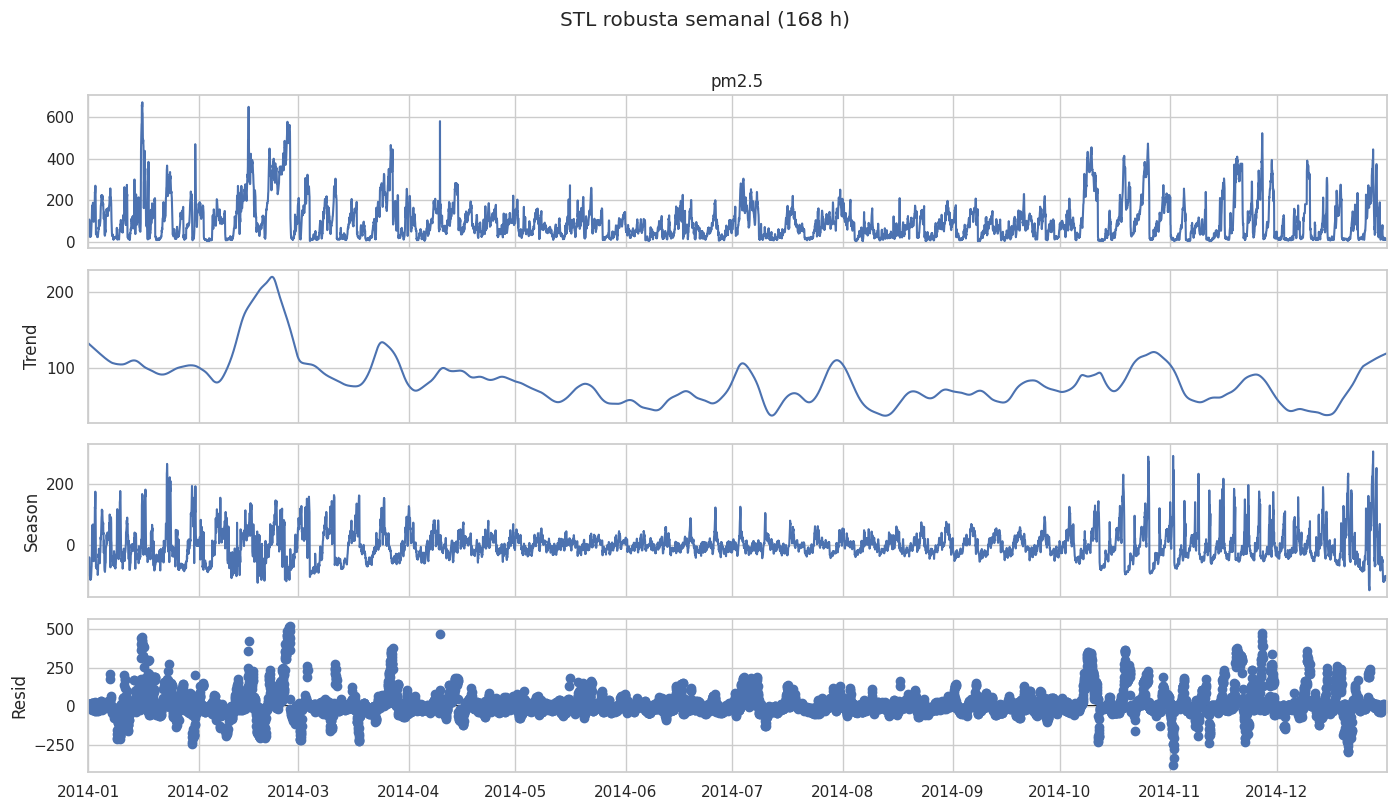

In [21]:
# STL robusta semanal (periodo 168) sobre una ventana anual.
stl168=STL(eda_y.loc["2014-01-01":"2014-12-31"],period=168,robust=True).fit(); fig=stl168.plot(); fig.set_size_inches(14,8); fig.suptitle("STL robusta semanal (168 h)",y=1.01); plt.tight_layout(); plt.show()


### 1.13 Fuerza estacional

**Qué hace.** Calcula la fuerza estacional como 1 − Var(residuo)/Var(estacional+residuo), en escala 0–1.

**Por qué importa.** Es una medida resumen comparable entre periodos: cuantifica qué proporción de la varianza (tras tendencia) se explica por el ciclo estacional.

**Cómo interpretar.** Los valores ejecutados son 0.049 (diaria) y 0.149 (semanal): ambas son bajas, pero la semanal triplica a la diaria. Esto sugiere que el patrón semanal aporta más estructura que el intradía, una señal útil al elegir órdenes estacionales.


In [22]:
# Fuerza estacional: 1 - Var(resid)/Var(estacional+resid); 0=nada, 1=determinista.
def strength(seasonal: pd.Series,resid: pd.Series)->float:
    return float(max(0,1-np.var(resid)/np.var(seasonal+resid)))
print("Diaria",strength(stl24.seasonal,stl24.resid),"Semanal",strength(stl168.seasonal,stl168.resid))


Diaria 0.04897126361019766 Semanal 0.1486655878216364


### 1.14 Estacionariedad

**Qué hace.** Plantea los dos tests complementarios que se usarán: ADF (H₀: raíz unitaria) y KPSS (H₀: estacionariedad), con α=0.05.

**Por qué importa.** Un modelo ARIMA requiere estacionariedad; el diagnóstico combinado ADF+KPSS evita conclusiones apresuradas (si ambos rechazan, sospeche de cambios de régimen).

**Cómo interpretar.** En nivel, ADF rechaza raíz unitaria (estadístico −21.55) y KPSS no rechaza estacionariedad (0.072, p≈0.1): la serie se comporta como estacionaria a efectos prácticos, coherente con un modelo (1,0,1) sin diferenciación regular.


### 1.15 Helper de tests

**Qué hace.** Define `stationarity_report`, una función reutilizable que ejecuta ADF y KPSS y devuelve una tabla estandarizada con hipótesis, estadístico, p-value y decisión.

**Por qué importa.** Unificar el reporte evita errores de interpretación y hace comparable el diagnóstico en nivel, diferencia regular y diferencia diaria.

**Cómo interpretar.** La primera llamada (serie en nivel) devuelve la fila ADF y la fila KPSS; fíjese en la columna `decision` antes de decidir si diferenciar.


In [23]:
# Helper de estacionariedad: ADF (H0: raiz unitaria) y KPSS (H0: estacionaria).
def stationarity_report(x: pd.Series,label: str,alpha: float=.05)->pd.DataFrame:
    x=x.dropna().astype(float); a=adfuller(x,autolag="AIC"); k=kpss(x,regression="c",nlags="auto")
    return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<alpha else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<alpha else "no rechazar H0"}])
stationarity_report(eda_y,"nivel")


,test,serie,H0,stat,p_value,decision
0,ADF,nivel,raíz unitaria,-21.549232,0.0,rechazar H0
1,KPSS,nivel,estacionaria,0.072265,0.1,no rechazar H0


### 1.16 Diferencia regular

**Qué hace.** Aplica la primera diferencia y repite el reporte de estacionariedad.

**Por qué importa.** Compara el diagnóstico tras diferenciar: si la serie ya era estacionaria en nivel, diferenciar es innecesario y solo añade varianza al pronóstico.

**Cómo interpretar.** ADF se vuelve más negativo (−36.87): la serie diferenciada es claramente estacionaria. La conclusión práctica es que no se necesita diferencia regular para el orden (1,0,1).


In [24]:
# Diagnostico tras la primera diferencia regular.
d1=eda_y.diff().dropna(); stationarity_report(d1,"diferencia regular")


,test,serie,H0,stat,p_value,decision
0,ADF,diferencia regular,raíz unitaria,-36.869493,0.0,rechazar H0
1,KPSS,diferencia regular,estacionaria,0.001769,0.1,no rechazar H0


### 1.17 Diferencia diaria

**Qué hace.** Aplica la diferencia estacional de 24 horas y reporta el diagnóstico.

**Por qué importa.** Evalúa si la estacionalidad diaria requiere diferenciación estacional o si basta el término estacional autorregresivo (1,0,0,24).

**Cómo interpretar.** ADF (−31.04) rechaza raíz unitaria: la serie diferenciada a 24 h es estacionaria. El modelo final usa estacionalidad sin diferenciar, consistente con estos tests.


In [25]:
# Diagnostico tras la diferencia estacional de 24 horas.
d24=eda_y.diff(24).dropna(); stationarity_report(d24,"diferencia diaria")


,test,serie,H0,stat,p_value,decision
0,ADF,diferencia diaria,raíz unitaria,-31.037656,0.0,rechazar H0
1,KPSS,diferencia diaria,estacionaria,0.001653,0.1,no rechazar H0


### 1.18 ACF

**Qué hace.** Dibuja la autocorrelación (ACF) hasta 168 lags sobre la diferencia diaria.

**Por qué importa.** El decaimiento de la ACF orienta la elección de los órdenes autorregresivos y de media móvil del SARIMA.

**Cómo interpretar.** Lags con autocorrelación fuera de la banda de confianza indican estructura no capturada; los picos en lags 24, 48, ... reflejan la persistencia diaria que el término estacional debe absorber.


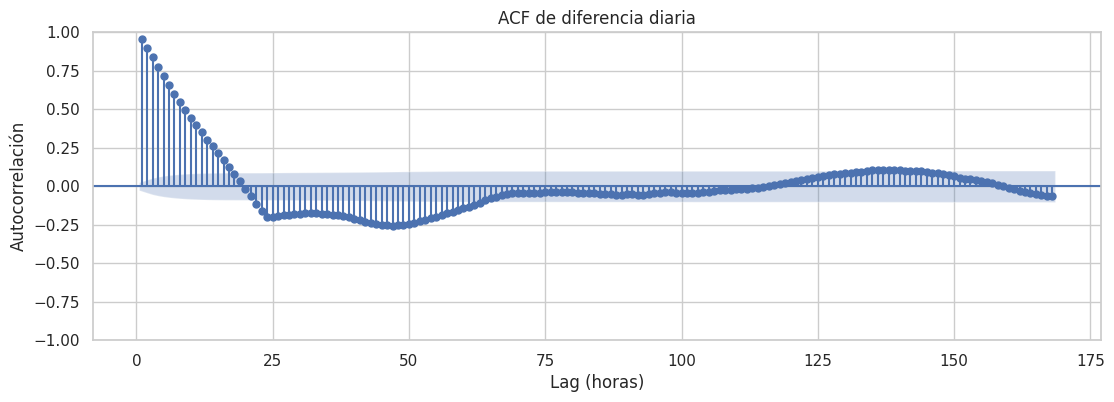

In [26]:
# ACF de la diferencia diaria: estructura autorregresiva y estacional residual.
fig,ax=plt.subplots(figsize=(13,4)); plot_acf(d24.tail(6000),lags=168,zero=False,ax=ax); ax.set(title="ACF de diferencia diaria",xlabel="Lag (horas)",ylabel="Autocorrelación"); plt.show()


### 1.19 PACF

**Qué hace.** Dibuja la autocorrelación parcial (PACF) hasta 72 lags.

**Por qué importa.** La PACF muestra la correlación *parcial* tras eliminar lags intermedios; junto con la ACF define el orden ARMA (aquí se opta por (1,0,1)).

**Cómo interpretar.** Picos significativos en los primeros lags y en múltiplos de 24 apoyan un componente autorregresivo corto más un componente estacional; la elección parsimoniosa (1,0,1)(1,0,0,24) se fija en la Sección 3.


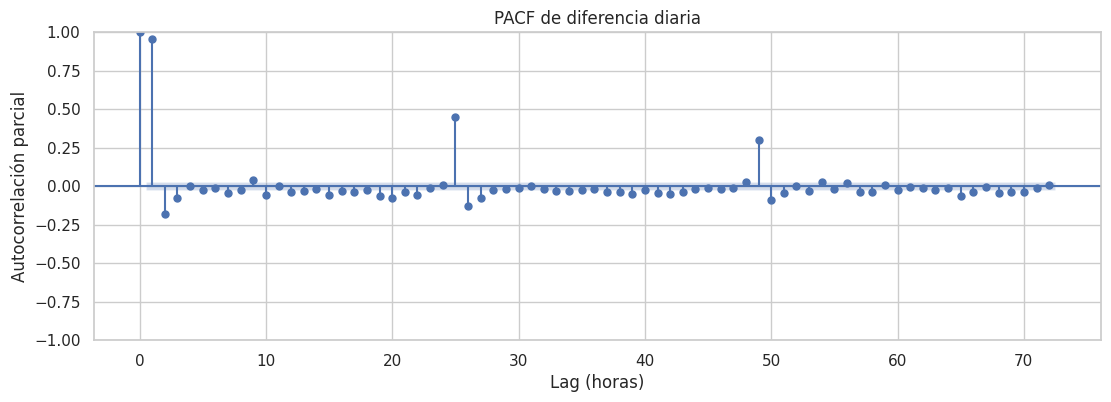

In [27]:
# PACF hasta 72 lags: ayuda a fijar el orden ARMA.
fig,ax=plt.subplots(figsize=(13,4)); plot_pacf(d24.tail(6000),lags=72,method="ywm",ax=ax); ax.set(title="PACF de diferencia diaria",xlabel="Lag (horas)",ylabel="Autocorrelación parcial"); plt.show()


### 1.20 Outliers

**Qué hace.** Detecta candidatos a outlier en los residuos de la STL diaria mediante desviación absoluta mediana (MAD), con umbral 4.5.

**Por qué importa.** Los 2,250 candidatos (4.5 desviaciones MAD) reflejan episodios extremos reales de contaminación; no se eliminan automáticamente porque en forecasting los picos son *información*, no ruido de medición.

**Cómo interpretar.** Los puntos en rojo son los candidatos; si se eliminaran, el modelo subestimaría sistemáticamente los episodios de mala calidad del aire, que son precisamente los más costosos para el negocio.


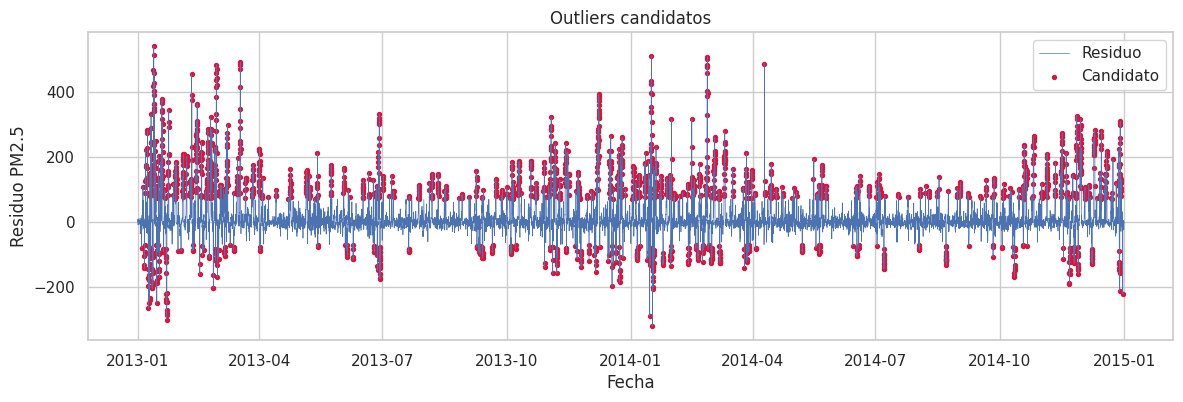

2250


In [28]:
# Outliers candidatos sobre residuos STL con MAD y umbral 4.5.
med=np.median(stl24.resid); mad=np.median(np.abs(stl24.resid-med)); rz=.6745*(stl24.resid-med)/mad; out=stl24.resid[np.abs(rz)>4.5]
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(stl24.resid.index,stl24.resid,lw=.5,label="Residuo"); ax.scatter(out.index,out,s=8,color="crimson",label="Candidato"); ax.set(title="Outliers candidatos",xlabel="Fecha",ylabel="Residuo PM2.5"); ax.legend(); plt.show(); print(len(out))


### 1.21 CUSUM

**Qué hace.** Calcula la suma acumulada de residuos estandarizados (CUSUM) para detectar cambios de nivel o de régimen.

**Por qué importa.** Un cambio estructural puede invalidar la estabilidad de los coeficientes entre folds; el máximo absoluto marca el punto más probable de cambio.

**Cómo interpretar.** El máximo absoluto ocurre el 2013-04-01 08:00: a partir de ahí conviene observar si los folds que caen en distintas épocas producen errores muy distintos (se retoma en 3.6 y 4.8).


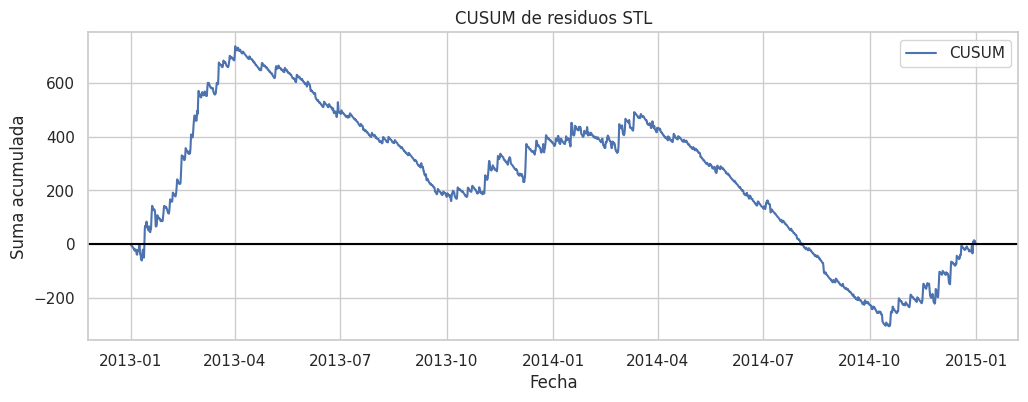

2013-04-01 08:00:00


In [29]:
# CUSUM de residuos estandarizados: detecta cambios de regimen, no causalidad.
z=(stl24.resid-stl24.resid.mean())/stl24.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM de residuos STL",xlabel="Fecha",ylabel="Suma acumulada"); ax.legend(); plt.show(); print(cs.abs().idxmax())


### 1.22 Covariables numéricas

**Qué hace.** Calcula la matriz de correlación de Spearman entre el target y las seis covariables numéricas.

**Por qué importa.** Detecta asociaciones monotónicas candidatas (p. ej., temperatura o presión con PM2.5) que justificarían incluir exógenas. Es *descriptivo*: correlación no implica causalidad ni garantiza ganancia predictiva.

**Cómo interpretar.** Fíjese en el signo y la magnitud frente a `pm2.5`. Una correlación alta no basta: la Sección 3 comprueba si la variable mejora la validación y es estable entre folds.


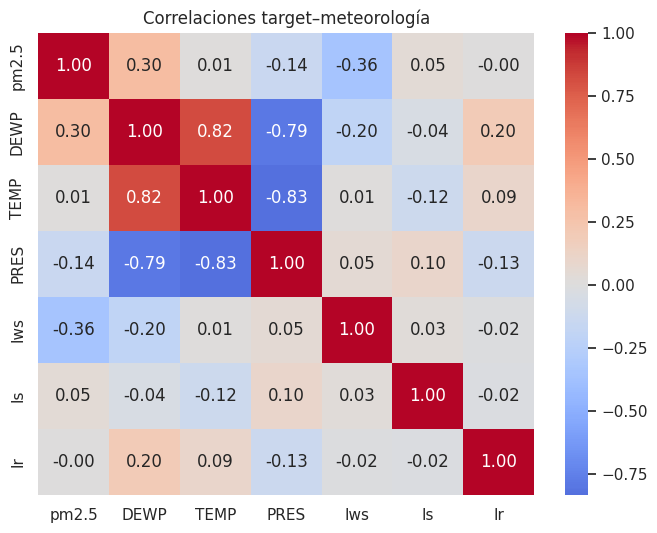

In [30]:
# Correlaciones de Spearman target-exogenas (descriptivo).
corr=raw[[TARGET,*EXOG_NUM]].corr(method="spearman"); fig,ax=plt.subplots(figsize=(8,6)); sns.heatmap(corr,annot=True,fmt=".2f",center=0,cmap="coolwarm",ax=ax); ax.set(title="Correlaciones target–meteorología"); plt.show()


### 1.23 Dirección del viento

**Qué hace.** Dibuja la distribución de PM2.5 para cada categoría de `cbwd`.

**Por qué importa.** Si la dirección del viento discrimina niveles de contaminación, será una candidata a exógena codificada one-hot.

**Cómo interpretar.** Las diferencias entre categorías (medianas y dispersión) indican poder discriminatorio; la categoría `cv` (viento calmado) suele asociarse a niveles altos. Este análisis se conecta con la estabilidad de coeficientes en 3.8–3.9.


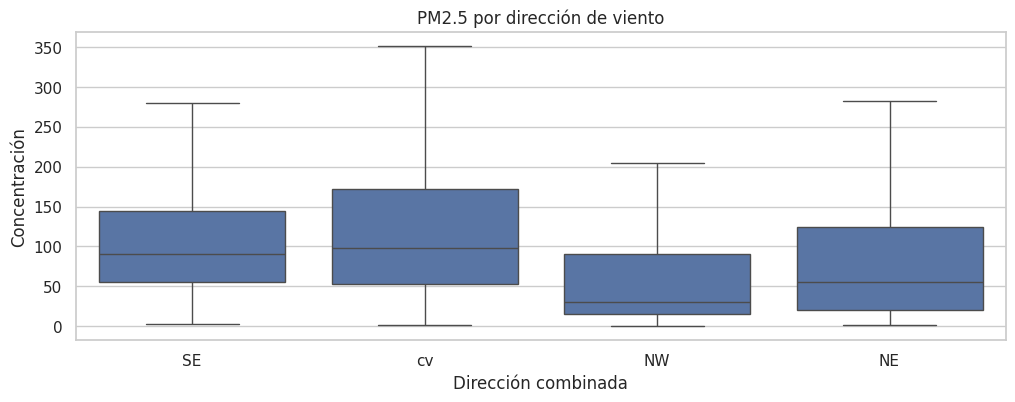

In [31]:
# Distribucion de PM2.5 por direccion del viento.
fig,ax=plt.subplots(); sns.boxplot(data=raw,x="cbwd",y=TARGET,showfliers=False,ax=ax); ax.set(title="PM2.5 por dirección de viento",xlabel="Dirección combinada",ylabel="Concentración"); plt.show()


## 2. Estrategia de validación

**Rolling-origin con 3 folds.** Cada fold usa 180 días anteriores y pronostica 7 días (168 h). Los orígenes están separados 30 días. La ventana limitada controla CPU y permite comparar regímenes recientes. Las imputaciones y escaladores se ajustan dentro de cada fold.

**Por qué importa este protocolo.** En series temporales un split aleatorio sería leakage: el test debe ser siempre *posterior* al train. Rolling-origin además entrega una distribución de errores entre folds, no un único número, y permite comparar SARIMA vs SARIMAX en igualdad de condiciones.

**Checkpoint.** Antes de continuar, verifique que entiende por qué la imputación y el escalado se reajustan dentro de cada fold (solo con datos de train) y qué pasaría si se calcularan una sola vez con todo el dataset.


### 2.1 Definición de folds

**Qué hace.** Construye las coordenadas (índices) de train y test para los tres folds: ventana móvil de 180 días (4,320 h) y test de 168 h, con orígenes cada 30 días.

**Por qué importa.** Materializa la estrategia en índices enteros sobre `raw`; con esto, cada fold se prepara de forma independiente y causal en 2.3.

**Cómo interpretar.** La tabla muestra los índices: `train_end = test_start` (el train termina justo donde empieza el test) y `test_end` del fold 3 coincide con el final de la serie (43,800). Ningún dato de test se usa para entrenar.


In [32]:
# Coordenadas de los 3 folds: 180 dias de train, 168 h de test, origenes cada 30 dias.
H=168; TRAIN_HOURS=24*180; origins=[len(raw)-H-24*60,len(raw)-H-24*30,len(raw)-H]
folds=[]
for i,o in enumerate(origins,1): folds.append({"fold":i,"train_start":o-TRAIN_HOURS,"train_end":o,"test_start":o,"test_end":o+H})
pd.DataFrame(folds)


,fold,train_start,train_end,test_start,test_end
0,1,37872,42192,42192,42360
1,2,38592,42912,42912,43080
2,3,39312,43632,43632,43800


### 2.2 Diagrama de folds

**Qué hace.** Dibuja las ventanas de train (colores) y test (negro) de cada fold sobre la línea temporal.

**Por qué importa.** Un diagrama explícito evita errores de definición: se ve que los tests son consecutivos al final de la serie y que las ventanas de train se desplazan hacia adelante.

**Cómo interpretar.** Los tres bloques negros (tests) no se solapan con los bloques de train que les preceden; la separación de 30 días entre orígenes aparece como el desplazamiento entre folds.


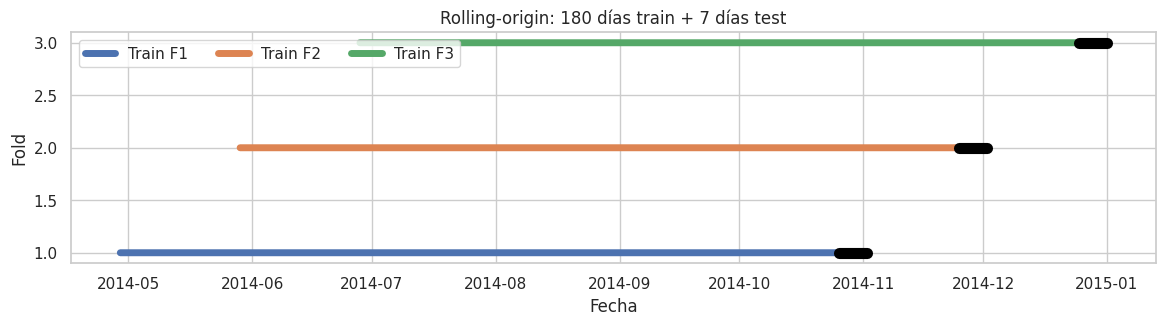

In [33]:
# Diagrama: bloques de train (colores) y test (negro) sobre la linea temporal.
fig,ax=plt.subplots(figsize=(14,3));
for f in folds:
    ax.plot(raw.ds.iloc[f["train_start"]:f["train_end"]],[f["fold"]]*TRAIN_HOURS,lw=5,label=f"Train F{f['fold']}"); ax.plot(raw.ds.iloc[f["test_start"]:f["test_end"]],[f["fold"]]*H,lw=8,color="black")
ax.set(title="Rolling-origin: 180 días train + 7 días test",xlabel="Fecha",ylabel="Fold"); ax.legend(ncol=3); plt.show()


### 2.3 Preparación causal

**Qué hace.** Define `prepare_fold`, que imputa el target dentro de cada fold con forward-fill limitado a 24 h y, para los gaps restantes, usa la mediana de train (test usa el último valor de train como fallback).

**Por qué importa.** Es la pieza anti-leakage central: la imputación de test nunca usa observaciones futuras ni estadísticas globales; de lo contrario, la mejora de SARIMAX sería artificial.

**Cómo interpretar.** La lista de tamaños `(4320, 168)` repetida tres veces confirma que todos los folds tienen la misma forma: 4,320 h de train y 168 h de test, listos para modelar.


In [34]:
# Preparacion causal por fold: ffill(24) + mediana de train; test usa el ultimo valor de train.
def prepare_fold(df: pd.DataFrame,f: dict)->tuple[pd.DataFrame,pd.DataFrame]:
    tr=df.iloc[f["train_start"]:f["train_end"]].copy(); te=df.iloc[f["test_start"]:f["test_end"]].copy(); med=float(tr[TARGET].median()); tr[TARGET]=tr[TARGET].ffill(limit=24).fillna(med); last=float(tr[TARGET].iloc[-1]); te[TARGET]=te[TARGET].ffill(limit=24).fillna(last)
    return tr,te
# Verificacion de tamanos (train, test) por fold.
[(len(prepare_fold(raw,f)[0]),len(prepare_fold(raw,f)[1])) for f in folds]


[(4320, 168), (4320, 168), (4320, 168)]

## 3. Modelado

> **Methodology Card — Exógenas**  
> Use una variable si mejora validación, es estable y existe en el horizonte. Meteorología observada en test representa un escenario oracle; producción necesita pronóstico meteorológico. `cbwd` se codifica one-hot. No use exógenas solo porque correlacionan.

### Escenario oracle: el techo optimista del SARIMAX

**Qué es.** Un escenario *oracle* usa en test información que en producción no se conocería a tiempo: aquí, las exógenas meteorológicas observadas durante los 7 días de test.

**Por qué es un techo.** Si el pronóstico fuera perfecto, el error del SARIMAX no podría ser menor que el obtenido con el clima real. Por tanto, la mejora de SARIMAX medida en este notebook (media 18.36 % en MAE) es el *máximo* alcanzable con esas covariables, no el esperado en producción.

**Cómo leer los resultados.** Los coeficientes y métricas de SARIMAX de las celdas siguientes deben interpretarse como *límite superior*: la decisión de desplegar requiere repetir la comparación con pronósticos meteorológicos reales o simulados con error (ver Ejercicio 4).

**Pausa para pensar.** ¿Qué pasaría con la ventaja de SARIMAX si la temperatura usada en test tuviera un error de 2 °C? ¿Y si el error creciera con el horizonte?

**Implicación de despliegue.** En producción, la mejora real dependerá de la calidad del pronóstico meteorológico externo disponible antes de emitir el pronóstico de PM2.5; el rendimiento esperado será ≤18.36 %, nunca mayor.

### 3.1 Métricas

$$MAE=n^{-1}\sum|e_t|,\quad RMSE=\sqrt{n^{-1}\sum e_t^2},\quad WAPE=100\sum|e_t|/\sum|y_t|$$

**Qué hace.** Fija las tres métricas de evaluación: MAE (error medio absoluto, en µg/m³), RMSE (penaliza más los errores grandes) y WAPE (error porcentual sobre la suma de valores absolutos).

**Por qué importa.** Para el caso de negocio, MAE/WAPE se interpretan como la desviación típica de una alerta: un MAE de ~85 µg/m³ significa que el pronóstico puede equivocarse en esa magnitud, con impacto en falsas alertas o alertas omitidas.

**Cómo interpretar.** Compare siempre las tres métricas: si RMSE >> MAE, hay episodios con errores grandes concentrados (colas), coherente con la distribución del target vista en 0.9.


### 3.2 Helpers

**Qué hace.** Define `metric_dict` (calcula MAE, RMSE, WAPE) y `exog_matrices`, que codifica `cbwd` en one-hot y estandariza las exógenas usando *solo* la media y desviación de train.

**Por qué importa.** Estandarizar con estadísticas globales filtraría información de test; hacerlo con las de train es la versión correcta del anti-patrón de la semana. La estandarización además hace comparables los coeficientes entre folds (3.8).

**Cómo interpretar.** `exog_matrices` devuelve dos matrices con las mismas columnas (mismo one-hot) pero estandarizadas con parámetros de train; las columnas constantes se protegen con `std().replace(0,1)`.


In [35]:
# Metricas y matriz exogena estandarizada con estadisticas de train.
def metric_dict(a: pd.Series,p: pd.Series)->dict[str,float]:
    e=np.asarray(a)-np.asarray(p); return {"MAE":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(e**2))),"WAPE_pct":float(100*np.sum(np.abs(e))/np.sum(np.abs(a)))}
def exog_matrices(tr: pd.DataFrame,te: pd.DataFrame)->tuple[pd.DataFrame,pd.DataFrame]:
    allx=pd.concat([tr[[*EXOG_NUM,"cbwd"]],te[[*EXOG_NUM,"cbwd"]]]); x=pd.get_dummies(allx,columns=["cbwd"],dtype=float); xtr=x.iloc[:len(tr)].copy(); xte=x.iloc[len(tr):].copy(); mu=xtr.mean(); sd=xtr.std().replace(0,1); return (xtr-mu)/sd,(xte-mu)/sd


### 3.3 Órdenes candidatos

**Qué hace.** Fija los órdenes SARIMA: (1,0,1) regular y (1,0,0,24) estacional, justificados por ACF/PACF y por la estacionalidad diaria.

**Por qué importa.** Un modelo parsimonioso (pocos parámetros) reduce sobreajuste y coste; los diagnósticos de la Sección 1 (estacionariedad, ACF/PACF, fuerza estacional) respaldan no diferenciar y usar un término estacional autorregresivo.

**Cómo interpretar.** El par (1,0,1)(1,0,0,24) es el mismo para SARIMA y SARIMAX: la única diferencia entre modelos será la presencia de exógenas, lo que hace limpia la comparación de mejora marginal.


In [36]:
# Ordenes parsimoniosos fijados por ACF/PACF y estacionalidad diaria.
ORDER=(1,0,1); SEASONAL_ORDER=(1,0,0,24); print(ORDER,SEASONAL_ORDER)


(1, 0, 1) (1, 0, 0, 24)


### 3.4 Backtesting SARIMA/SARIMAX

**Qué hace.** Ajusta SARIMA y SARIMAX en cada fold, pronostica 168 h y guarda métricas, AIC, coeficientes, residuos e intervalos. `simple_differencing=True` reduce el coste computacional.

**Por qué importa.** Es el experimento central: con el mismo protocolo y los mismos órdenes, la única diferencia es el uso de las exógenas meteorológicas *observadas*. Cualquier mejora de SARIMAX es, por tanto, atribuible a las covariables… en el escenario oracle.

**Cómo interpretar.** SARIMAX gana en MAE en los tres folds (84.65 vs 105.73; 99.28 vs 113.05; 71.03 vs 92.20). Obsérvese también que el AIC de SARIMAX es *peor* (mayor) en los tres folds: la ganancia en MAE no proviene de un mejor ajuste de verosimilitud, sino del uso de información futura. Esto es una señal típica de escenario oracle.


In [37]:
# Backtesting: ajusta SARIMA y SARIMAX en cada fold y guarda metricas, AIC, coeficientes y residuos.
results=[]; forecasts={}; coef_rows=[]; residuals={}; intervals={}; t0=time.time()
for f in folds:
    tr,te=prepare_fold(raw,f); ytr=tr[TARGET].astype(float); yte=te[TARGET].astype(float); xtr,xte=exog_matrices(tr,te)
    for name,use_x in [("SARIMA",False),("SARIMAX",True)]:
        model=SARIMAX(ytr,exog=xtr if use_x else None,order=ORDER,seasonal_order=SEASONAL_ORDER,trend="c",enforce_stationarity=False,enforce_invertibility=False,simple_differencing=True)
        fit=model.fit(disp=False,maxiter=60); pred=fit.get_forecast(steps=H,exog=xte if use_x else None); mean=pd.Series(np.asarray(pred.predicted_mean),index=te.ds); ci=pred.conf_int(alpha=.05); forecasts[(f["fold"],name)]=mean; intervals[(f["fold"],name)]=(np.asarray(ci.iloc[:,0]),np.asarray(ci.iloc[:,1])); residuals[(f["fold"],name)]=pd.Series(fit.resid).dropna(); results.append({"fold":f["fold"],"model":name,**metric_dict(yte,mean.values),"AIC":fit.aic})
        if use_x:
            for param,value in fit.params.items():
                if param in xtr.columns: coef_rows.append({"fold":f["fold"],"feature":param,"coefficient":value})
print("Segundos:",round(time.time()-t0,1)); result_df=pd.DataFrame(results); result_df


Segundos: 202.4


,fold,model,MAE,RMSE,WAPE_pct,AIC
0,1,SARIMA,105.732705,129.684123,99.435146,35974.622870
1,1,SARIMAX,84.654339,102.683578,79.612231,36155.671730
2,2,SARIMA,113.049916,143.677308,74.717282,35854.927414
3,2,SARIMAX,99.275783,138.238718,65.613642,36597.794784
4,3,SARIMA,92.201181,120.641862,76.072087,36840.259729
5,3,SARIMAX,71.028714,102.441659,58.603398,37827.710138


In [38]:
# ------------------------------------------------------------------
# Funciones reutilizables para validacion rolling-origin con embargo.
# No modifican la logica de los folds usados arriba: replican la misma
# definicion y anaden un parametro `gap` (embargo) para evitar que
# observaciones muy cercanas al origen filtren informacion futura.
# ------------------------------------------------------------------
def rolling_origin_folds(n, h, train_hours, step, gap=0, n_folds=3):
    """Genera n_folds ventanas rolling-origin con embargo opcional.

    Parametros
    ----------
    n : int           Numero total de observaciones.
    h : int           Horizonte de test (horas).
    train_hours : int Tamano de la ventana de train (horas).
    step : int        Separacion entre origenes (horas).
    gap : int         Embargo entre train y test (horas); 0 = sin embargo.
    n_folds : int     Numero de folds.

    Devuelve una lista de dicts con las mismas claves que `folds`.
    """
    origins = [n - h - gap - (n_folds - 1 - k) * step for k in range(n_folds)]
    return [
        {
            "fold": i,
            "train_start": o - train_hours,
            "train_end": o,
            "test_start": o,
            "test_end": o + h,
        }
        for i, o in enumerate(origins, 1)
    ]

# Verificacion: sin embargo, la funcion reproduce exactamente los folds del notebook.
generated = rolling_origin_folds(len(raw), h=H, train_hours=TRAIN_HOURS, step=24 * 30, gap=0)
assert generated == folds, "La funcion reutilizable debe replicar la definicion de folds"

# Con embargo de 24 h, el test se desplaza: util para la Semana 4 (ML).
embargo = rolling_origin_folds(len(raw), h=H, train_hours=TRAIN_HOURS, step=24 * 30, gap=24)
print("Folds con embargo 24 h (test_start desplazado):")
print(pd.DataFrame(embargo)[["fold", "train_start", "test_start", "test_end"]])

# Tabla de estabilidad entre folds: media, std, minimo y maximo por modelo.
def stability_summary(df, metric="MAE"):
    """Resume media, desviacion, minimo y maximo de una metrica por modelo."""
    return df.groupby("model")[metric].agg(["mean", "std", "min", "max"])

print("\nEstabilidad de MAE entre folds por modelo:")
stability_summary(result_df)


Folds con embargo 24 h (test_start desplazado):
   fold  train_start  test_start  test_end
0     1        37848       42168     42336
1     2        38568       42888     43056
2     3        39288       43608     43776

Estabilidad de MAE entre folds por modelo:


,mean,std,min,max
model,,,,
SARIMA,103.661267,10.577598,92.201181,113.049916
SARIMAX,84.986279,14.126460,71.028714,99.275783


### 3.5 Mejora marginal

**Qué hace.** Calcula la mejora porcentual de MAE de SARIMAX frente a SARIMA en cada fold.

**Por qué importa.** Una mejora *promedio* puede ocultar folds donde la exógena no ayuda; la lectura fold a fold evalúa consistencia.

**Cómo interpretar.** Las mejoras ejecutadas son 19.94 %, 12.18 % y 22.96 %: la exógena ayuda en los tres folds, pero con amplitud variable. La media (18.36 %, celda final) es el valor reportado por el notebook.


In [39]:
# Mejora marginal por fold: 100*(SARIMA-SARIMAX)/SARIMA; positiva favorece exogenas.
pivot=result_df.pivot(index="fold",columns="model",values="MAE"); pivot["improvement_pct"]=100*(pivot.SARIMA-pivot.SARIMAX)/pivot.SARIMA; pivot


model,SARIMA,SARIMAX,improvement_pct
fold,,,
1,105.732705,84.654339,19.935522
2,113.049916,99.275783,12.184116
3,92.201181,71.028714,22.963336


### 3.6 Resumen de robustez

**Qué hace.** Agrega media y desviación estándar de MAE, RMSE y WAPE entre folds por modelo.

**Por qué importa.** Complementa la mejora promedio con estabilidad: un modelo con menor MAE medio pero alta dispersión es menos confiable para operación.

**Cómo interpretar.** SARIMAX reduce el MAE medio de 103.66 a 84.99 (≈18 % sobre la media), pero su desviación (14.13) es mayor que la de SARIMA (10.58): la ventaja es real pero inestable entre folds, un punto a favor de la cautela antes de desplegar.


In [40]:
# Resumen de robustez: media y desviacion entre folds por modelo.
result_df.groupby("model")[["MAE","RMSE","WAPE_pct"]].agg(["mean","std"])


MAE                   RMSE              WAPE_pct           
               mean        std        mean        std       mean        std
model                                                                      
SARIMA   103.661267  10.577598  131.334431  11.606058  83.408172  13.896287
SARIMAX   84.986279  14.126460  114.454652  20.597961  67.943090  10.696378

### Preguntas para comparar SARIMA vs SARIMAX

**De negocio.** ¿La reducción de MAE de SARIMAX (media 18.36 %; de 103.66 a 84.99 µg/m³) se traduce en menos alertas fallidas o en alertas más tempranas? ¿Cuántas falsas alertas estamos dispuestos a pagar por esa mejora?

**Técnica.** ¿La mejora es consistente entre folds (19.94 %, 12.18 %, 22.96 %) o depende de un régimen? ¿Los coeficientes de las exógenas son estables (3.8–3.9) o cambian de signo? ¿El AIC empeora pese a mejorar MAE?

**De producción.** ¿De dónde saldrán las covariables en el momento de pronosticar? ¿Con qué error y con qué latencia? ¿El pipeline de imputación y estandarización por fold está implementado en producción tal como se validó?

**Pausa para pensar.** Si solo pudiera desplegar un modelo esta semana (SARIMA o SARIMAX), ¿qué evidencia adicional pediría antes de decidir?

> **Nota sobre el valor reportado.** La celda final del notebook imprime una mejora media de **18.36 %** (media de las mejoras por fold; sobre las medias de MAE 103.66 vs 84.99 equivale a ≈18.0 %). Si el README del curso cita 20.7 %, ese valor no coincide con los outputs ejecutados aquí; la cifra vigente para este notebook es la calculada en sus propias celdas.

> **Nota inferencial.** Que la temperatura o el punto de rocío tengan coeficientes significativos en SARIMAX no implica que *causen* la variación de PM2.5: comparten estacionalidad y ciclos diarios con la contaminación. El modelo captura asociación temporal útil para predecir, no mecanismo causal; una política de reducción de contaminación (nivel de decisión distinto) requeriría evidencia causal, no solo predictiva.

> **Lectura operativa.** La reducción de MAE (≈18.7 µg/m³, de 103.66 a 84.99) se lee frente a los umbrales de alerta que use la autoridad ambiental: si el umbral ronda niveles del orden de 150 µg/m³, un margen de error de esa magnitud puede ser la diferencia entre activar o no una alerta. La pregunta operativa es si esa mejora justifica la dependencia de un pronóstico meteorológico externo en producción.

### 3.7 Gráfico de folds

**Qué hace.** Dibuja el MAE por fold para ambos modelos.

**Por qué importa.** La forma de las dos curvas muestra si la ventaja de SARIMAX es constante o depende del régimen (por ejemplo, folds más fríos o más contaminados).

**Cómo interpretar.** La distancia vertical entre curvas es la mejora de cada fold; si las curvas fueran paralelas, la ventaja sería estable; si se cruzan, habría folds donde SARIMA gana.


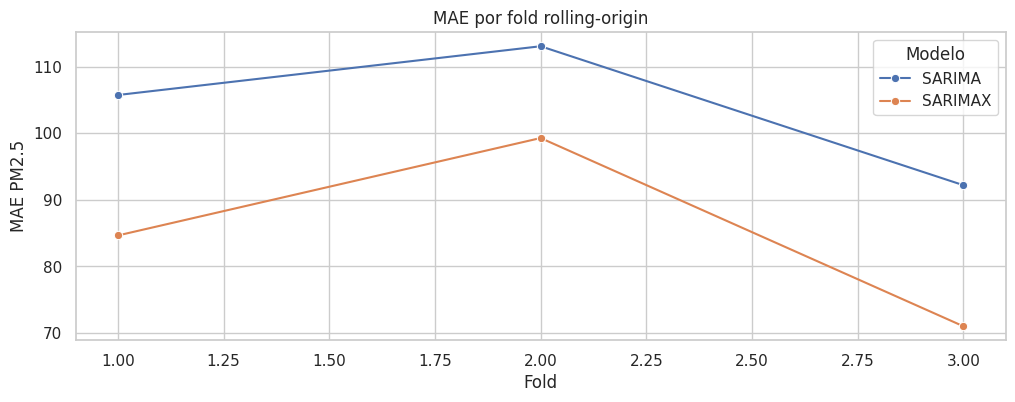

In [41]:
# MAE por fold: lectura visual de la ventaja de SARIMAX.
fig,ax=plt.subplots(); sns.lineplot(data=result_df,x="fold",y="MAE",hue="model",marker="o",ax=ax); ax.set(title="MAE por fold rolling-origin",xlabel="Fold",ylabel="MAE PM2.5"); ax.legend(title="Modelo"); plt.show()


### 3.8 Estabilidad de coeficientes

**Qué hace.** Dibuja la evolución entre folds de los coeficientes estandarizados de SARIMAX para las diez features con mayor magnitud media.

**Por qué importa.** Un coeficiente que cambia de signo o de magnitud entre folds indica que la relación exógena→target no es estable, y la ganancia podría no generalizar.

**Cómo interpretar.** Los coeficientes con mayor magnitud media (p. ej. temperatura y punto de rocío) deben mantener signo consistente; las líneas que cruzan el cero repetidamente son candidatas a inestabilidad (se cuantifica en 3.9).

Un coeficiente inestable entre folds es una señal de que la relación observada puede ser espuria o dependiente del período específico. En producción, esto se traduce en: *no confiar en esa covariable como predictor estable sin monitorear su coeficiente a lo largo del tiempo*. La estabilidad del coeficiente es una condición de desplegabilidad, no solo de calidad estadística.

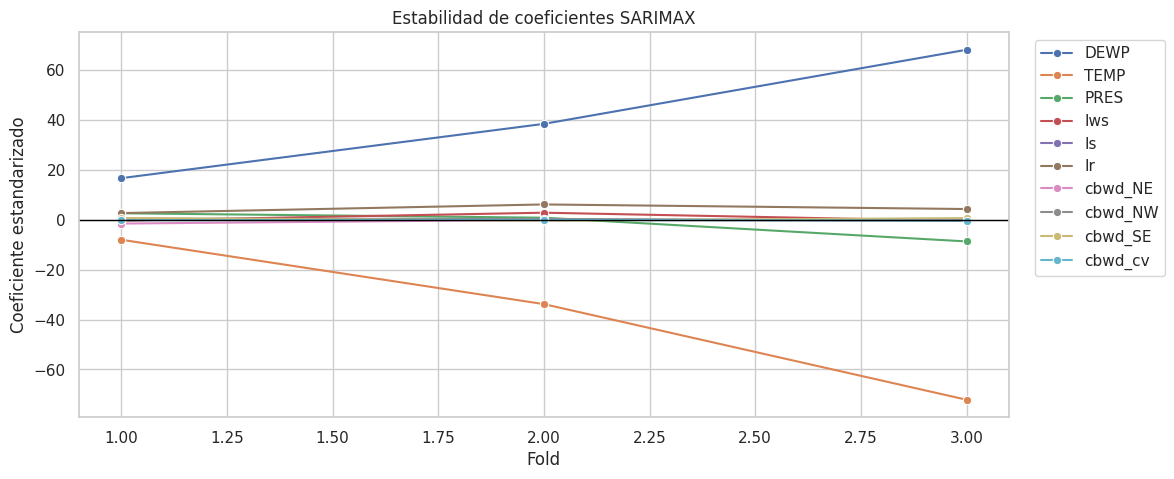

In [42]:
# Coeficientes estandarizados de SARIMAX por fold (top-10 por magnitud media).
coef_df=pd.DataFrame(coef_rows); top=coef_df.groupby("feature").coefficient.apply(lambda x:np.mean(np.abs(x))).nlargest(10).index; show=coef_df[coef_df.feature.isin(top)]; fig,ax=plt.subplots(figsize=(12,5)); sns.lineplot(data=show,x="fold",y="coefficient",hue="feature",marker="o",ax=ax); ax.axhline(0,color="black",lw=1); ax.set(title="Estabilidad de coeficientes SARIMAX",xlabel="Fold",ylabel="Coeficiente estandarizado"); ax.legend(bbox_to_anchor=(1.02,1),loc="upper left"); plt.show()


### 3.9 Variación de coeficientes

**Qué hace.** Calcula la inestabilidad relativa de cada coeficiente como |std|/|mean| (con protección numérica) y ordena las features de mayor a menor.

**Por qué importa.** Cuantifica lo visto en 3.8: valores altos de inestabilidad relativa (≳1.5) indican coeficientes que cambian mucho entre folds, poco confiables para interpretación de negocio.

**Cómo interpretar.** En la salida ejecutada, PRES (3.52), Iws (2.73) y cbwd_NW (2.20) lideran la inestabilidad, mientras que DEWP (0.63) e Ir (0.39) son las más estables. La ganancia de SARIMAX se apoya en features estables como DEWP, no en las ruidosas.


In [43]:
# Inestabilidad relativa: std/|mean| por feature; alta = poco confiable.
stability=coef_df.groupby("feature").coefficient.agg(["mean","std"]); stability["relative_instability"]=stability["std"]/(stability["mean"].abs()+1e-9); stability.sort_values("relative_instability",ascending=False).head(12)


,mean,std,relative_instability
feature,,,
PRES,-1.725926,6.070681,3.517347
Iws,0.690328,1.883039,2.727746
cbwd_NW,0.179141,0.393720,2.197827
Is,-0.046857,0.081158,1.732051
cbwd_SE,0.379265,0.591758,1.560274
cbwd_NE,-0.571267,0.806702,1.412128
cbwd_cv,-0.155099,0.162375,1.046913
TEMP,-37.967380,32.284009,0.850309
DEWP,41.126858,25.846996,0.628470


### 3.10 Forecast último fold

**Qué hace.** Dibuja el pronóstico de ambos modelos frente al valor real en el último fold (7 días).

**Por qué importa.** La métrica resume, pero el gráfico muestra *dónde* falla cada modelo: seguimiento de picos, desfases o sesgos sistemáticos.

**Cómo interpretar.** Observe si SARIMAX anticipa mejor los episodios altos (gracias a la meteorología observada) y si ambos modelos tienden a subestimar los picos, lo que se cuantifica como bias en 4.8.


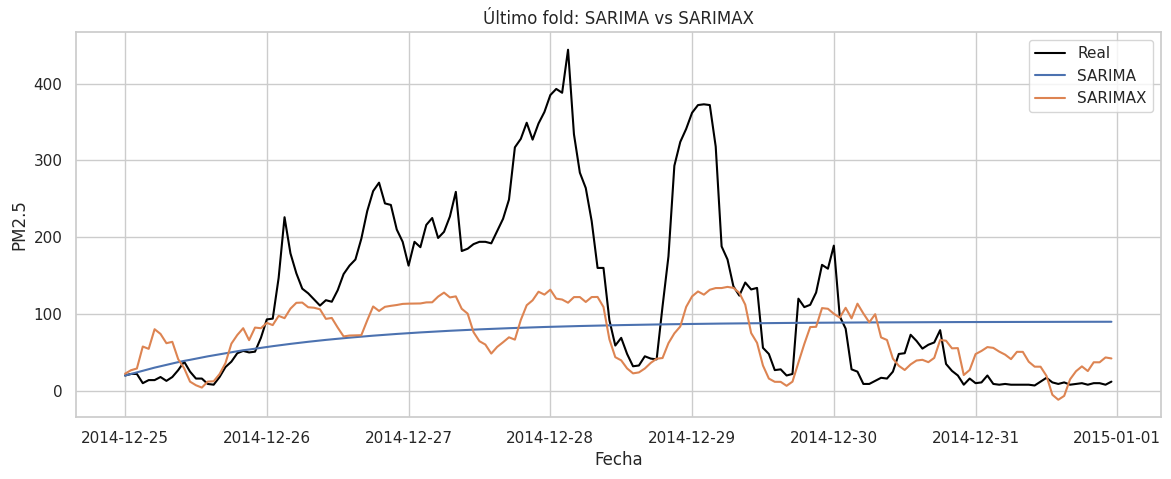

In [44]:
# Comparacion visual del ultimo fold: real vs SARIMA vs SARIMAX.
f=folds[-1]; _,te=prepare_fold(raw,f); fig,ax=plt.subplots(figsize=(14,5)); ax.plot(te.ds,te[TARGET],color="black",label="Real");
for name in ["SARIMA","SARIMAX"]: ax.plot(te.ds,forecasts[(3,name)].values,label=name)
ax.set(title="Último fold: SARIMA vs SARIMAX",xlabel="Fecha",ylabel="PM2.5"); ax.legend(); plt.show()


### 3.11 Intervalo SARIMAX

**Qué hace.** Dibuja el pronóstico puntual de SARIMAX con su intervalo de confianza del 95 % en el último fold.

**Por qué importa.** La banda de incertidumbre es la materia prima de decisiones operativas (umbrales de alerta); una banda mal calibrada produce falsas alarmas o alarmas omitidas.

**Cómo interpretar.** Compare la cobertura visual con la nominal: si el real sale a menudo de la banda, la cobertura empírica estará por debajo de 0.95, como confirma la celda 4.5 (0.77, 0.68, 0.86).


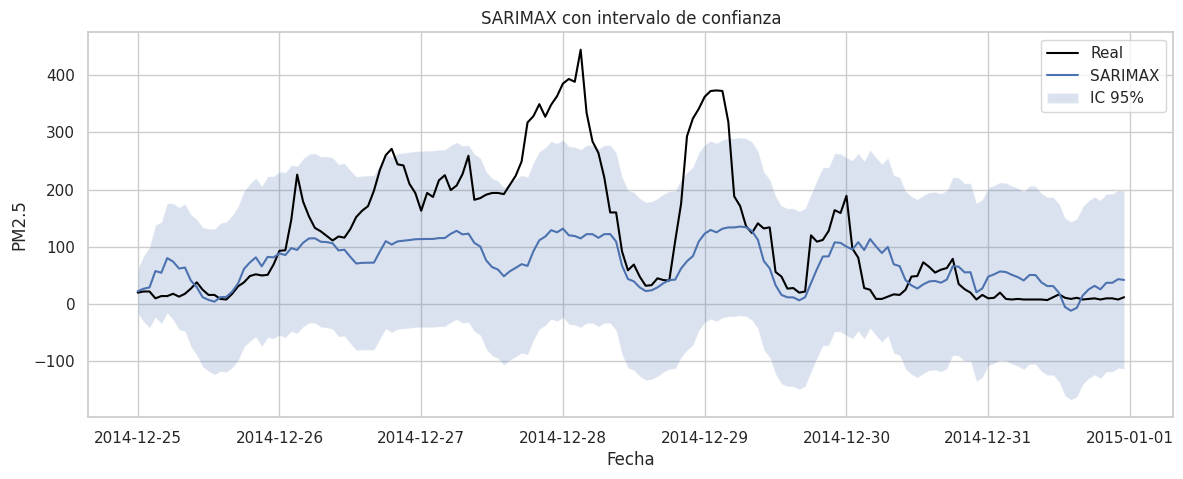

In [45]:
# Intervalo de confianza 95% del SARIMAX en el ultimo fold.
lo,hi=intervals[(3,"SARIMAX")]; pred=forecasts[(3,"SARIMAX")]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(te.ds,te[TARGET],color="black",label="Real"); ax.plot(te.ds,pred.values,label="SARIMAX"); ax.fill_between(te.ds,lo,hi,alpha=.2,label="IC 95%"); ax.set(title="SARIMAX con intervalo de confianza",xlabel="Fecha",ylabel="PM2.5"); ax.legend(); plt.show()


## 4. Análisis posterior (post-modeling)

Los diagnósticos se reportan por fold para no ocultar cambios de régimen.

**Objetivo de la sección.** Validar que los residuos de SARIMAX cumplen los supuestos del modelo (independencia, normalidad, homocedasticidad) y evaluar la calibración de los intervalos y la distribución del error por horizonte y nivel. Esto determina si el modelo es explotable tal cual o si necesita correcciones (p. ej., intervalos conformales).


### 4.1 Ljung–Box por fold

**Qué hace.** Aplica el test de Ljung–Box (H₀: sin autocorrelación hasta lag 24) a los residuos de SARIMAX en cada fold.

**Por qué importa.** Autocorrelación residual indica estructura no modelada; además degrada los intervalos de confianza gaussianos.

**Cómo interpretar.** En los tres folds se rechaza H₀ (p < 0.05): quedan autocorrelaciones significativas. Es una limitación conocida del SARIMAX parsimonioso y un argumento para la Semana 4 (features + ML).


In [46]:
# Ljung-Box por fold: autocorrelacion residual hasta lag 24.
diag=[]
for fold in [1,2,3]:
    r=residuals[(fold,"SARIMAX")]; lb=acorr_ljungbox(r,lags=[24],return_df=True).iloc[0]; diag.append({"fold":fold,"test":"Ljung-Box","H0":"sin autocorrelación","stat":lb.lb_stat,"p_value":lb.lb_pvalue,"decision":"rechazar H0" if lb.lb_pvalue<.05 else "no rechazar H0"})
pd.DataFrame(diag)


,fold,test,H0,stat,p_value,decision
0,1,Ljung-Box,sin autocorrelación,45.559066,4.999239e-03,rechazar H0
1,2,Ljung-Box,sin autocorrelación,48.869824,1.966807e-03,rechazar H0
2,3,Ljung-Box,sin autocorrelación,98.149140,6.202812e-11,rechazar H0


### 4.2 Normalidad por fold

**Qué hace.** Aplica Jarque–Bera (H₀: normalidad) a los residuos por fold.

**Por qué importa.** La normalidad de los residuos es supuesto de los intervalos gaussianos y de la inferencia de coeficientes.

**Cómo interpretar.** Se rechaza la normalidad en los tres folds con estadísticos enormes: las colas de la distribución del error son pesadas, coherentes con los episodios extremos de PM2.5.


In [47]:
# Jarque-Bera por fold: normalidad de los residuos.
rows=[]
for fold in [1,2,3]:
    jb=jarque_bera(residuals[(fold,"SARIMAX")]); rows.append({"fold":fold,"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0"})
pd.DataFrame(rows)


,fold,test,H0,stat,p_value,decision
0,1,Jarque-Bera,normalidad,131926.587927,0.0,rechazar H0
1,2,Jarque-Bera,normalidad,20851.699007,0.0,rechazar H0
2,3,Jarque-Bera,normalidad,18731.072339,0.0,rechazar H0


### 4.3 ARCH por fold

**Qué hace.** Aplica el test ARCH LM (H₀: homocedasticidad condicional) a los residuos.

**Por qué importa.** Heterocedasticidad condicional (volatilidad que se agrupa) invalida intervalos de confianza de ancho constante: en episodios de contaminación el error es mayor.

**Cómo interpretar.** Se rechaza H₀ en los tres folds: la varianza del error no es constante. Esto explica la mala cobertura del IC 95 % (4.5) y motiva intervalos conformales o modelos probabilísticos (Semana 8).


In [48]:
# ARCH LM por fold: homocedasticidad condicional.
rows=[]
for fold in [1,2,3]:
    a=het_arch(residuals[(fold,"SARIMAX")],nlags=24); rows.append({"fold":fold,"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"})
pd.DataFrame(rows)


,fold,test,H0,stat,p_value,decision
0,1,ARCH LM,homocedasticidad,867.090380,1.352301e-167,rechazar H0
1,2,ARCH LM,homocedasticidad,111.035111,3.717305e-13,rechazar H0
2,3,ARCH LM,homocedasticidad,190.420760,7.373808e-28,rechazar H0


### 4.4 QQ-plot último fold

**Qué hace.** Dibuja el QQ-plot de los residuos de SARIMAX del último fold contra la normal.

**Por qué importa.** Visualiza la desviación de normalidad: en qué cola (izquierda/derecha) se concentra el exceso.

**Cómo interpretar.** Puntos que se alejan de la diagonal en las colas confirman lo que Jarque–Bera rechazó numéricamente: errores extremos más frecuentes que una gaussiana.


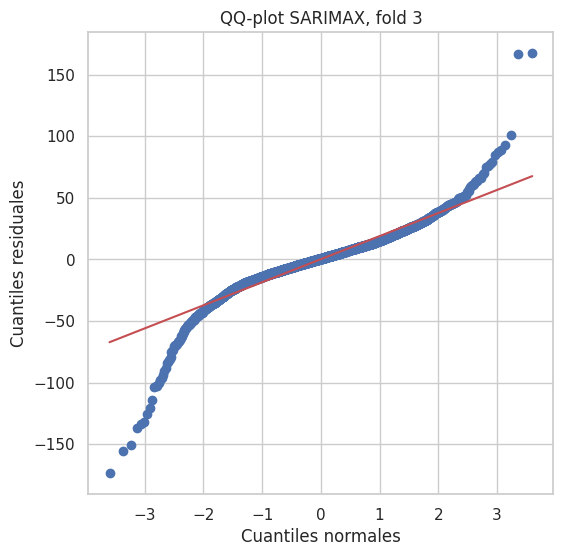

In [49]:
# QQ-plot de los residuos del ultimo fold: desviacion de la normalidad.
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(residuals[(3,"SARIMAX")],dist="norm",plot=ax); ax.set(title="QQ-plot SARIMAX, fold 3",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()


### 4.5 Cobertura 95 %

**Qué hace.** Calcula la proporción de observaciones reales dentro del IC 95 % nominal por fold.

**Por qué importa.** Es la prueba de calibración de los intervalos: si la cobertura empírica está muy por debajo de 0.95, el intervalo es optimista y las alertas basadas en él serán más inciertas de lo reportado.

**Cómo interpretar.** La cobertura ejecutada es 0.77, 0.68 y 0.86: siempre inferior a 0.95. Combinado con Ljung–Box y ARCH, la conclusión es que los intervalos gaussianos subestiman la incertidumbre real.


In [50]:
# Cobertura empirica del IC 95% por fold (nominal 0.95).
cov=[]
for f in folds:
    _,tef=prepare_fold(raw,f); lo,hi=intervals[(f["fold"],"SARIMAX")]; cov.append({"fold":f["fold"],"nominal":.95,"empirical":float(np.mean((tef[TARGET].values>=lo)&(tef[TARGET].values<=hi)))})
pd.DataFrame(cov)


,fold,nominal,empirical
0,1,0.95,0.767857
1,2,0.95,0.684524
2,3,0.95,0.863095


### 4.6 Error por horizonte

**Qué hace.** Calcula el MAE por hora del horizonte (1–168) agregando los tres folds.

**Por qué importa.** Muestra cómo se degrada el error con la distancia: si crece rápido, el modelo es útil solo para horizontes cortos (p. ej., alertas a 24–48 h).

**Cómo interpretar.** La forma de la curva informa el diseño operativo: un umbral de alerta debe considerar que el error a 7 días es mayor que a 24 h, por lo que las decisiones de restricción deben usar horizontes cortos.


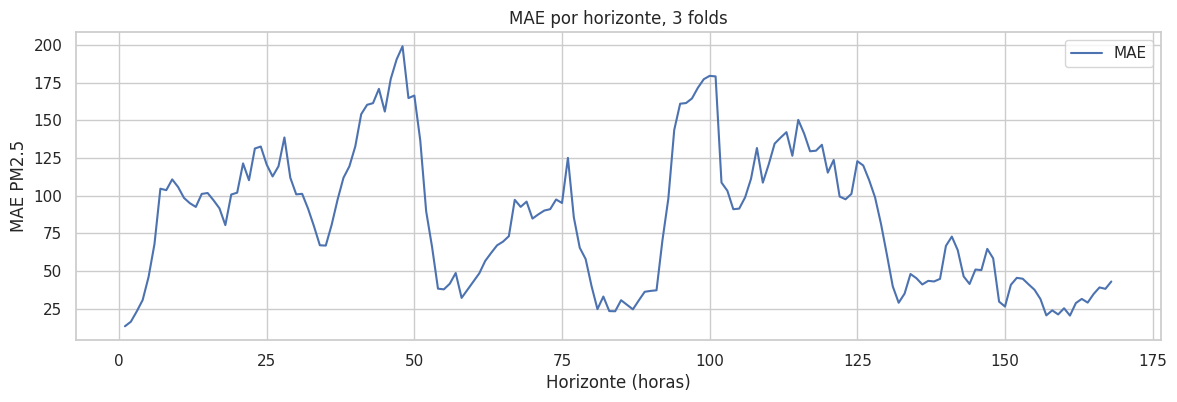

In [51]:
# MAE por horizonte (1-168) agregando los tres folds.
eh=[]
for f in folds:
    _,tef=prepare_fold(raw,f); p=forecasts[(f["fold"],"SARIMAX")].values
    for h,(a,pp) in enumerate(zip(tef[TARGET].values,p),1): eh.append({"fold":f["fold"],"horizon":h,"abs_error":abs(a-pp)})
eh=pd.DataFrame(eh); by=eh.groupby("horizon").abs_error.mean(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(by.index,by,label="MAE"); ax.set(title="MAE por horizonte, 3 folds",xlabel="Horizonte (horas)",ylabel="MAE PM2.5"); ax.legend(); plt.show()


### 4.7 Error por nivel

**Qué hace.** Segmenta el error por nivel de PM2.5 (bajo/medio/alto según cuartiles del test) y agrega media, mediana y conteo.

**Por qué importa.** No todos los errores cuestan lo mismo: fallar en un episodio alto (p. ej., no emitir una alerta) tiene mayor costo que fallar en un día limpio.

**Cómo interpretar.** El error medio en el segmento alto (178.85) triplica al del segmento bajo (57.98): el modelo falla más justo donde el negocio más necesita precisión. Este es el punto de partida de la decisión ejecutiva.


In [52]:
# Error por nivel de PM2.5: cuartiles del test por fold.
segments=[]
for f in folds:
    _,tef=prepare_fold(raw,f); p=forecasts[(f["fold"],"SARIMAX")].values; q1,q3=tef[TARGET].quantile([.25,.75]); label=pd.cut(tef[TARGET],[-np.inf,q1,q3,np.inf],labels=["bajo","medio","alto"])
    segments.append(pd.DataFrame({"segment":label,"abs_error":np.abs(tef[TARGET].values-p)}))
pd.concat(segments).groupby("segment",observed=True).abs_error.agg(["mean","median","count"])


,mean,median,count
segment,,,
bajo,57.984295,37.168585,131
medio,52.956298,39.942900,250
alto,178.846076,163.355191,123


### 4.8 Bias por fold

**Qué hace.** Calcula el bias medio (real − pronóstico) por fold; positivo implica subpronóstico sistemático.

**Por qué importa.** Un bias grande y estable permite corregir el pronóstico con un ajuste simple; un bias que cambia de signo entre folds indica inestabilidad de régimen.

**Cómo interpretar.** Los valores ejecutados son −4.42 (fold 1, leve sobrepronóstico), +84.43 (fold 2) y +49.68 (fold 3): en los dos últimos folds SARIMAX subestima de forma importante, un riesgo operativo para alertas de calidad del aire.


In [53]:
# Bias por fold: media de (real - pronostico); positivo = subpronostico.
bias=[]
for f in folds:
    _,tef=prepare_fold(raw,f); p=forecasts[(f["fold"],"SARIMAX")].values; bias.append({"fold":f["fold"],"bias":float(np.mean(tef[TARGET].values-p))})
pd.DataFrame(bias)


,fold,bias
0,1,-4.418912
1,2,84.429271
2,3,49.679435


## 5. Lecciones metodológicas

1. Eliminar 24 filas iniciales no resolvió 2,043 nulos interiores.  
2. La imputación debe ajustarse dentro de cada fold.  
3. SARIMAX con clima observado es un escenario oracle; producción requiere forecasts de clima.  
4. La mejora media debe acompañarse de estabilidad entre folds y coeficientes.  
5. Intervalos gaussianos pierden calibración con autocorrelación y ARCH.  

**Lectura con números del notebook.** La mejora media de SARIMAX fue 18.36 % en MAE (mejoras por fold de 19.94 %, 12.18 % y 22.96 %), pero esa ganancia es un techo oracle: usa clima observado en test. Además, el MAE medio pasó de 103.66 (SARIMA) a 84.99 (SARIMAX), con una desviación entre folds mayor (14.13 vs 10.58), y la cobertura del IC 95 % quedó en 0.77–0.86, por debajo del 0.95 nominal.

**Checkpoint.** Antes de pasar a la Sección 6, explique con sus palabras por qué el AIC de SARIMAX es peor que el de SARIMA y, aun así, su MAE es mejor; y por qué esa combinación es una señal de escenario oracle.

**Conexión:** Semana 4 reemplaza forma paramétrica por features y ML, con embargo explícito.


## 6. Ejercicios propuestos

1. **Fácil:** compare ffill límite 6, 12 y 24.  
2. **Intermedio:** incluya estacionalidad semanal mediante Fourier.  
3. **Intermedio:** retire una covariable por vez y mida mejora marginal.  
4. **Difícil:** use pronósticos meteorológicos simulados con error realista.  
5. **Difícil:** implemente intervalos conformales por fold.

**Ejercicio 4 fortalecido (oracle vs producción).** Parta de la celda 3.4 y simule dos escenarios de covariable: (a) *oracle*, clima observado (el actual del notebook), y (b) *producción*, clima simulado como `observado + ruido` con error realista (p. ej., normal con desviación creciente con el horizonte, del orden de 1–2 °C para TEMP). Reentrene SARIMAX en ambos escenarios, compare MAE/WAPE por fold y cuantifique cuántos puntos porcentuales de la mejora de 18.36 % (oracle) se pierden al pasar a producción. **Pregunta guía:** ¿cuánta precisión meteorológica se necesita para que SARIMAX siga superando a SARIMA?


## Decisión ejecutiva y checklist de reproducibilidad

**Decisión ejecutiva (recomendación).** **No desplegar SARIMAX en producción** basándose solo en los resultados de este notebook: su mejora (media 18.36 % en MAE) se obtuvo con clima *observado* (escenario oracle). Antes de desplegar se debe evaluar SARIMAX con pronósticos meteorológicos reales o simulados con error realista (Ejercicio 4) y verificar que la ventaja sobre SARIMA se mantiene. Como plan alternativo inmediato, SARIMA (MAE medio 103.66) es un baseline honesto y sin dependencias externas, válido para alertas de horizonte corto.

**Checklist de reproducibilidad.** Para que cualquier persona (o el CI) pueda repetir este análisis:

1. Entorno con `requirements.txt` y Python 3.10+; semilla (seed) fijada en 42.
2. Dataset `data/03_beijing/beijing_pm25.csv` con contrato verificado (43,800 × 14; 2,043 nulos en `pm2.5`).
3. Imputación causal por fold (`prepare_fold`) y estandarización con estadísticas de train (`exog_matrices`).
4. Protocolo rolling-origin explícito: 3 folds, 180 días train, 168 h test, orígenes cada 30 días.
5. Métricas reportadas fold a fold (MAE, RMSE, WAPE) y resumen de estabilidad (media/std/min/max).
6. Diagnóstico de residuos (Ljung–Box, Jarque–Bera, ARCH) y cobertura empírica del IC.
7. Interpretación explícita del escenario oracle: no citar la mejora de SARIMAX como si fuera alcanzable en producción.


In [54]:
# Cierre: resumen final y mejora media de SARIMAX sobre SARIMA.
print("Notebook 3 completado.")
print(result_df.groupby("model").MAE.mean())
print("Mejora media SARIMAX (%):",pivot.improvement_pct.mean())


Notebook 3 completado.
model
SARIMA     103.661267
SARIMAX     84.986279
Name: MAE, dtype: float64
Mejora media SARIMAX (%): 18.36099124618855
